# 📝 **Solución de Guía #2**

## 👥 **Integrantes**:  
- *Miguel Alejandro Díaz Cely*  
- *Jose Fernando motta Mendez*
- *Emily Del Carmen Tench Pérez*  


# Modelado Supervisado con Selección de Características y Árboles de Decisión

## Heart Disease UCI Dataset

### Introducción

Este notebook implementa un análisis completo para predecir la presencia de enfermedad cardíaca utilizando técnicas de Machine Learning. Se han incorporado mejoras significativas que incluyen:
- Análisis exploratorio de datos (EDA) avanzado con detección de outliers
- Múltiples técnicas de selección de características
- Modelado con Árboles de Decisión y comparación con otros algoritmos
- Evaluación exhaustiva y optimización del modelo
- Análisis de estabilidad y regularización
- Validación cruzada estratificada


## 1️⃣ Carga y EDA básico

### Cargando las librerías necesarias

In [1]:
# Librerías básicas para manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para separar datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split, StratifiedKFold

# Para preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer  # Agregamos esto para manejar valores faltantes

# Para selección de características
from sklearn.feature_selection import SelectKBest, f_classif, RFE, chi2
from sklearn.feature_selection import mutual_info_classif

# Para modelado con árboles de decisión y otros modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Para evaluación del modelo
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay  # Añadido para visualización de matrices de confusión

# Para búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV, cross_val_score

# Para pipeline
from sklearn.pipeline import Pipeline

# Herramientas adicionales
from scipy import stats
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('ggplot')
sns.set(style='whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

### Cargando los datos

In [2]:
# Cargando el dataset
df = pd.read_csv('heart_disease_uci (1).csv')

In [3]:
# Visualizando las primeras 5 filas
print("Mostrando las primeras 5 filas del dataset:")
display(df.head())

Mostrando las primeras 5 filas del dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Análisis descriptivo básico

In [4]:
# Información general del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.shape[1]

16

In [6]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
# Verificando valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [8]:
# Verificando duplicados
print(f"\nCantidad de registros duplicados: {df.duplicated().sum()}")


Cantidad de registros duplicados: 0


### Análisis Avanzado de Outliers

¡Advertencia! Se encontraron valores NaN en los datos.
Valores NaN por columna:
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
dtype: int64
Variable age: 0 outliers detectados (0.00%)
Variable trestbps: 8 outliers detectados (0.87%)
Variable chol: 3 outliers detectados (0.33%)
Variable thalch: 1 outliers detectados (0.11%)
Variable oldpeak: 7 outliers detectados (0.76%)
Variable ca: 20 outliers detectados (2.17%)


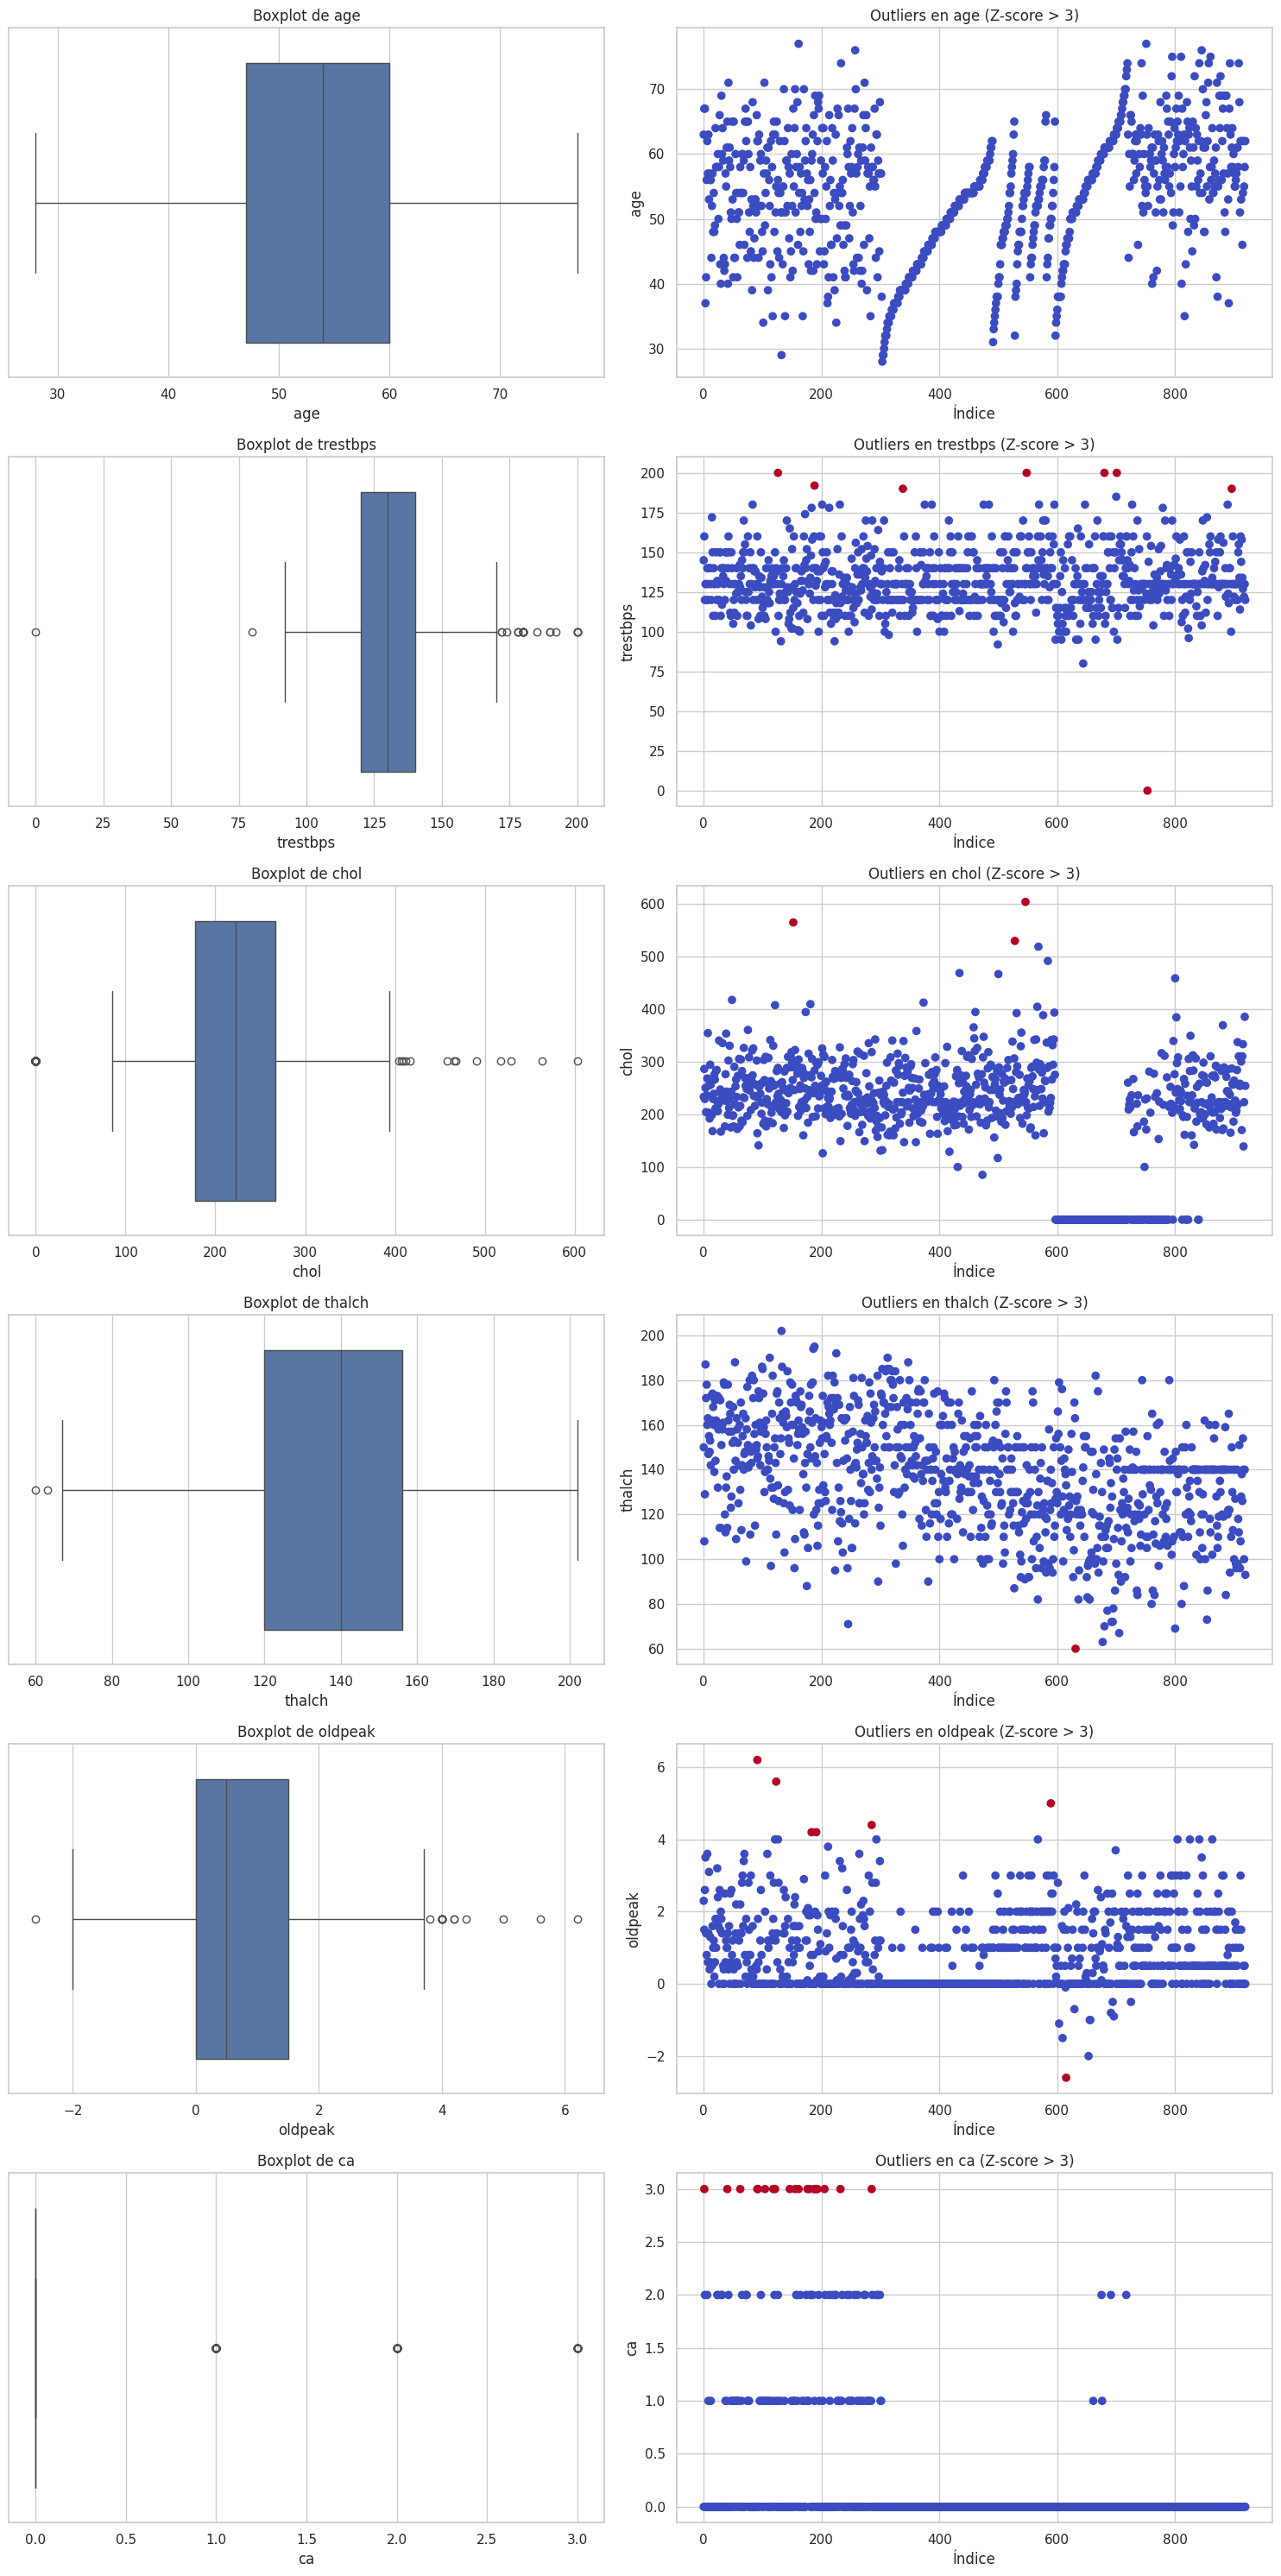

In [9]:
# Identificando variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['id', 'num']]

# Verificando y manejando valores NaN antes del análisis de outliers
if df[numeric_cols].isnull().sum().sum() > 0:
    print("¡Advertencia! Se encontraron valores NaN en los datos.")
    print("Valores NaN por columna:")
    print(df[numeric_cols].isnull().sum())

    # Imputamos para el análisis de outliers
    df_for_outliers = df.copy()
    imputer = SimpleImputer(strategy='median')
    df_for_outliers[numeric_cols] = imputer.fit_transform(df_for_outliers[numeric_cols])
else:
    df_for_outliers = df

# Análisis de outliers usando el método IQR
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 5*len(numeric_cols)))
axes = axes.reshape(-1, 2) if len(numeric_cols) > 1 else axes.reshape(1, 2)

for i, col in enumerate(numeric_cols):
    # Boxplot
    sns.boxplot(x=df_for_outliers[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot de {col}')

    # Z-score y marcado de outliers
    z_scores = np.abs(stats.zscore(df_for_outliers[col]))
    outliers = z_scores > 3
    axes[i, 1].scatter(range(len(df_for_outliers)), df_for_outliers[col], c=outliers, cmap='coolwarm')
    axes[i, 1].set_title(f'Outliers en {col} (Z-score > 3)')
    axes[i, 1].set_xlabel('Índice')
    axes[i, 1].set_ylabel(col)

    # Reportando outliers
    n_outliers = outliers.sum()
    print(f"Variable {col}: {n_outliers} outliers detectados ({n_outliers/len(df_for_outliers)*100:.2f}%)")

plt.tight_layout()
plt.show()

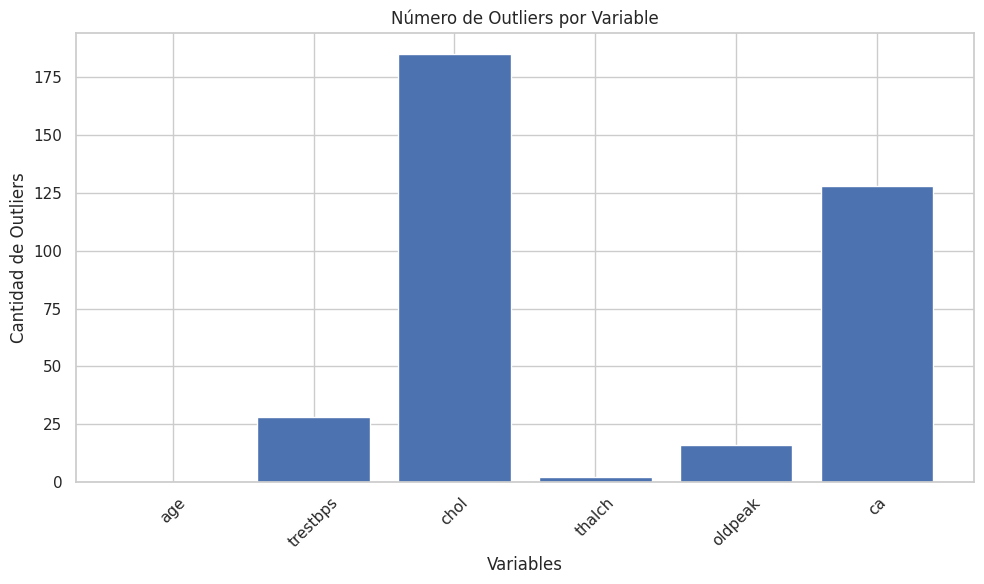

In [10]:
# Análisis de outliers multivariantes usando el método IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Detectando outliers para cada variable numérica
outliers_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df_for_outliers, col)
    outliers_summary[col] = len(outliers)

# Visualizando resumen de outliers
plt.figure(figsize=(10, 6))
plt.bar(outliers_summary.keys(), outliers_summary.values())
plt.title('Número de Outliers por Variable')
plt.xlabel('Variables')
plt.ylabel('Cantidad de Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis de las variables categóricas


Variables categóricas: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


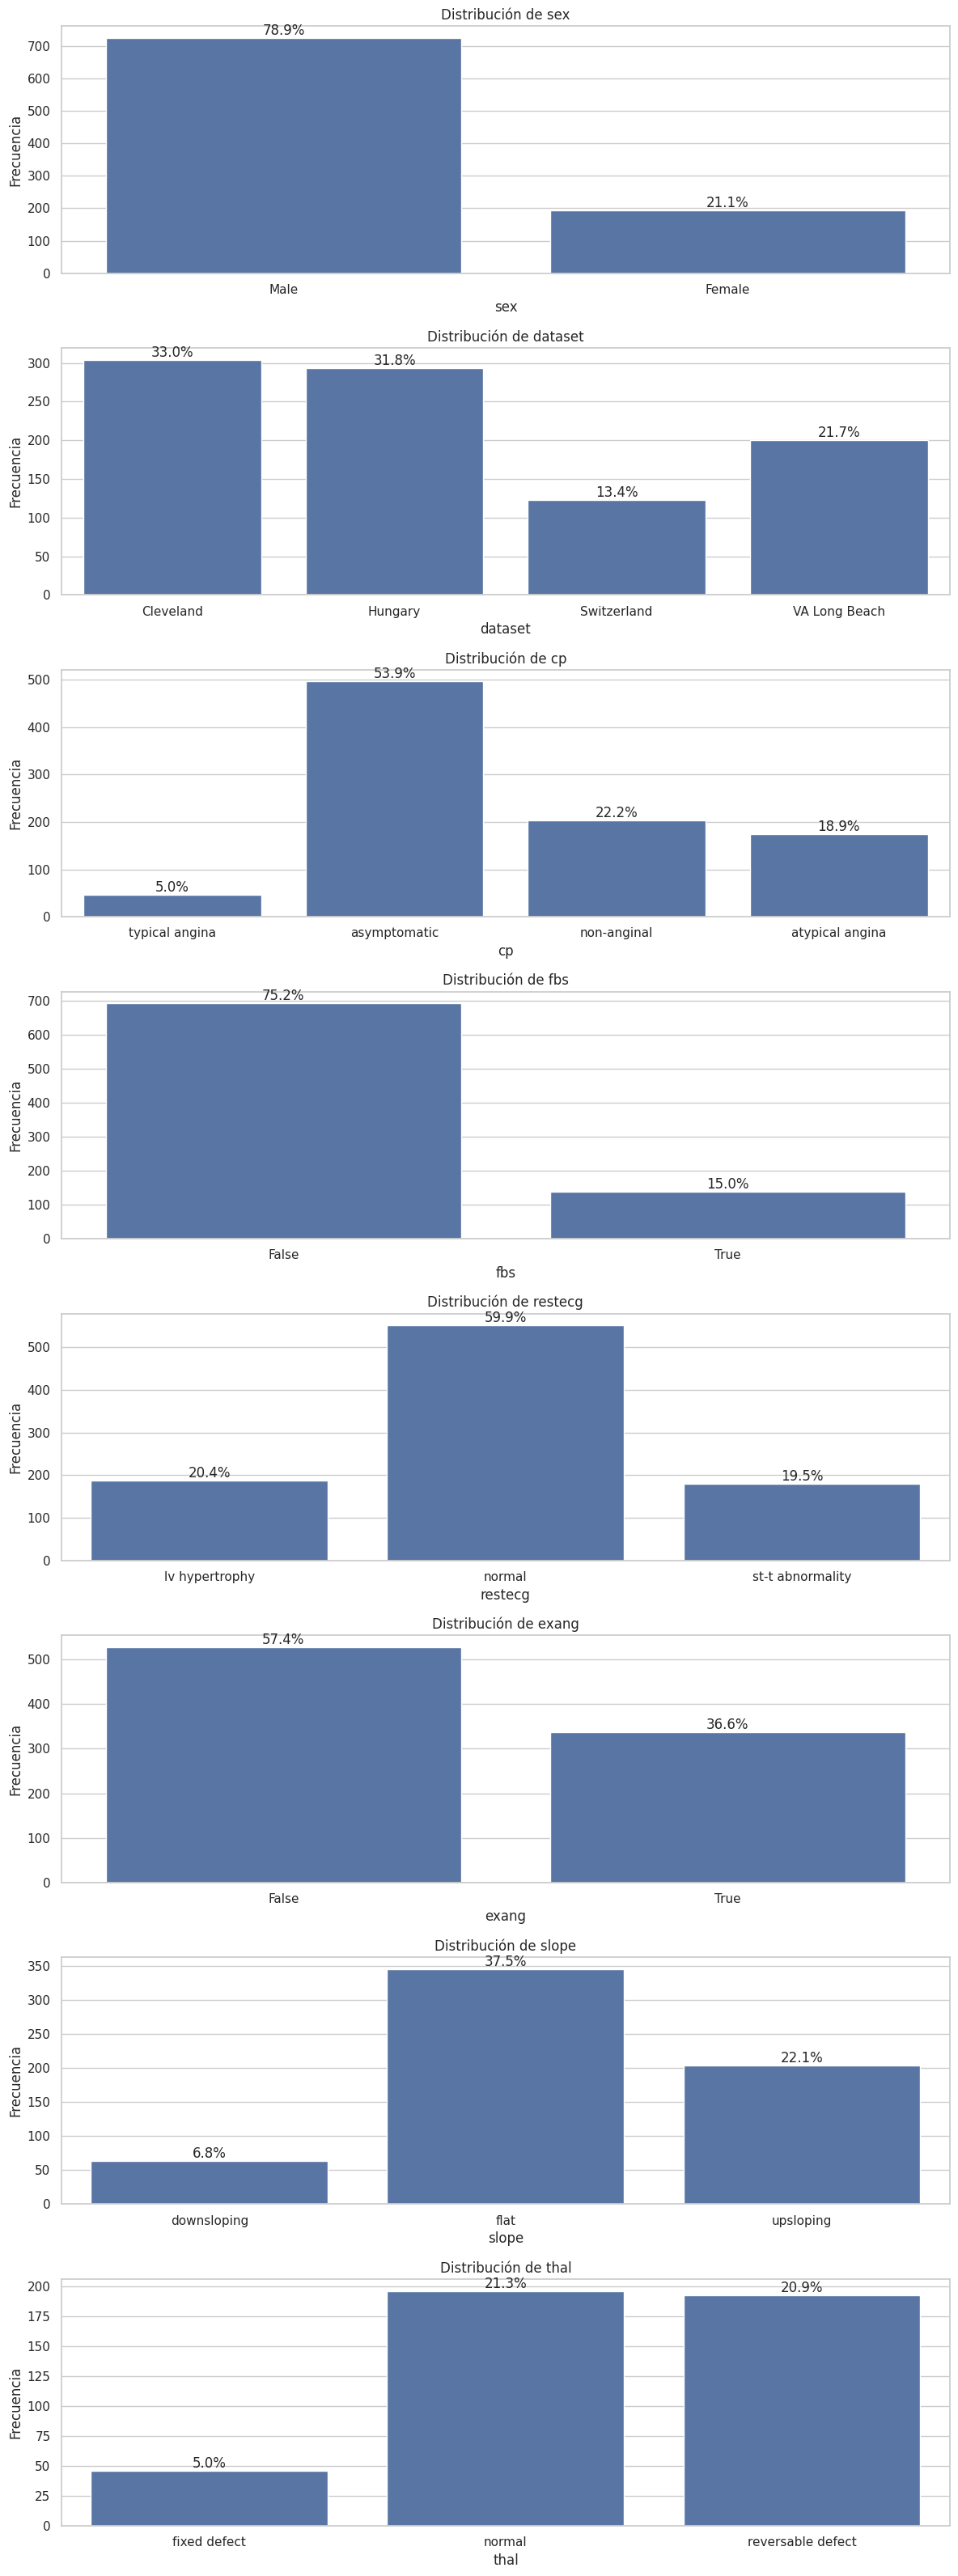

In [11]:
# Identificando variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas: {categorical_cols}")

if categorical_cols:
    # Explorando la distribución de cada variable categórica
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, len(categorical_cols)*4))

    if len(categorical_cols) == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols):
        sns.countplot(x=col, data=df, ax=axes[i])
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_ylabel('Frecuencia')

        # Añadiendo porcentajes
        total = len(df[col])
        for p in axes[i].patches:
            percentage = f'{100 * p.get_height() / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            axes[i].annotate(percentage, (x, y), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

### Análisis de la variable objetivo

In [12]:
# Variable objetivo: 'num' (presencia de enfermedad cardíaca)
# Valores: 0 = ausencia, 1-4 = presencia con diferentes niveles de gravedad

# Analizando la distribución
print("Distribución de la variable objetivo (num):")
print(df['num'].value_counts())

# Para simplificar, convertimos a problema binario (0 = ausencia, 1 = presencia)
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
print("\nDistribución simplificada (target):")
print(df['target'].value_counts())
print(f"Porcentaje de casos positivos: {100 * df['target'].mean():.2f}%")

Distribución de la variable objetivo (num):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Distribución simplificada (target):
target
1    509
0    411
Name: count, dtype: int64
Porcentaje de casos positivos: 55.33%


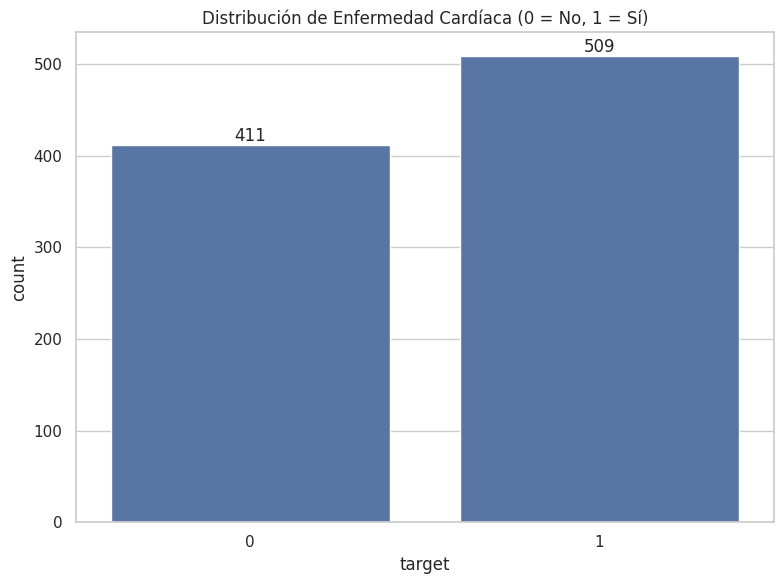

In [13]:
# Visualización
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Distribución de Enfermedad Cardíaca (0 = No, 1 = Sí)')
for i in plt.gca().containers:
    plt.gca().bar_label(i, fmt='%.0f')
plt.tight_layout()
plt.show()


In [14]:
# Análisis de balance de clases
n_positivos = df['target'].sum()
n_negativos = len(df) - n_positivos
ratio = n_positivos / n_negativos
print(f"\nCasos positivos: {n_positivos} ({n_positivos/len(df)*100:.2f}%)")
print(f"Casos negativos: {n_negativos} ({n_negativos/len(df)*100:.2f}%)")
print(f"Ratio positivo/negativo: {ratio:.2f}")


Casos positivos: 509 (55.33%)
Casos negativos: 411 (44.67%)
Ratio positivo/negativo: 1.24


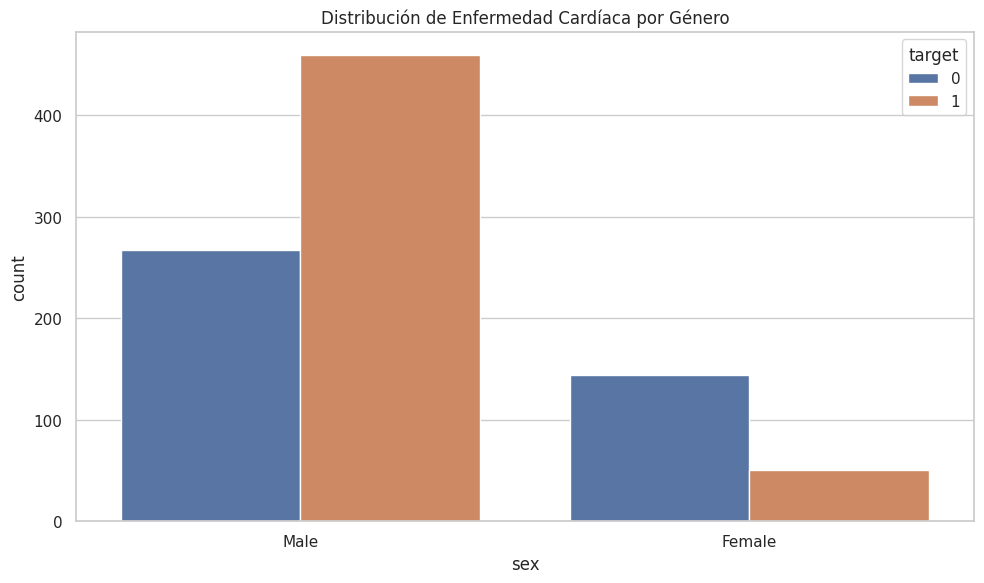

In [15]:
# Análisis por características demográficas
if 'sex' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='sex', hue='target', data=df)
    plt.title('Distribución de Enfermedad Cardíaca por Género')
    plt.tight_layout()
    plt.show()

### Análisis de Variables Numéricas

Variables numéricas para análisis: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


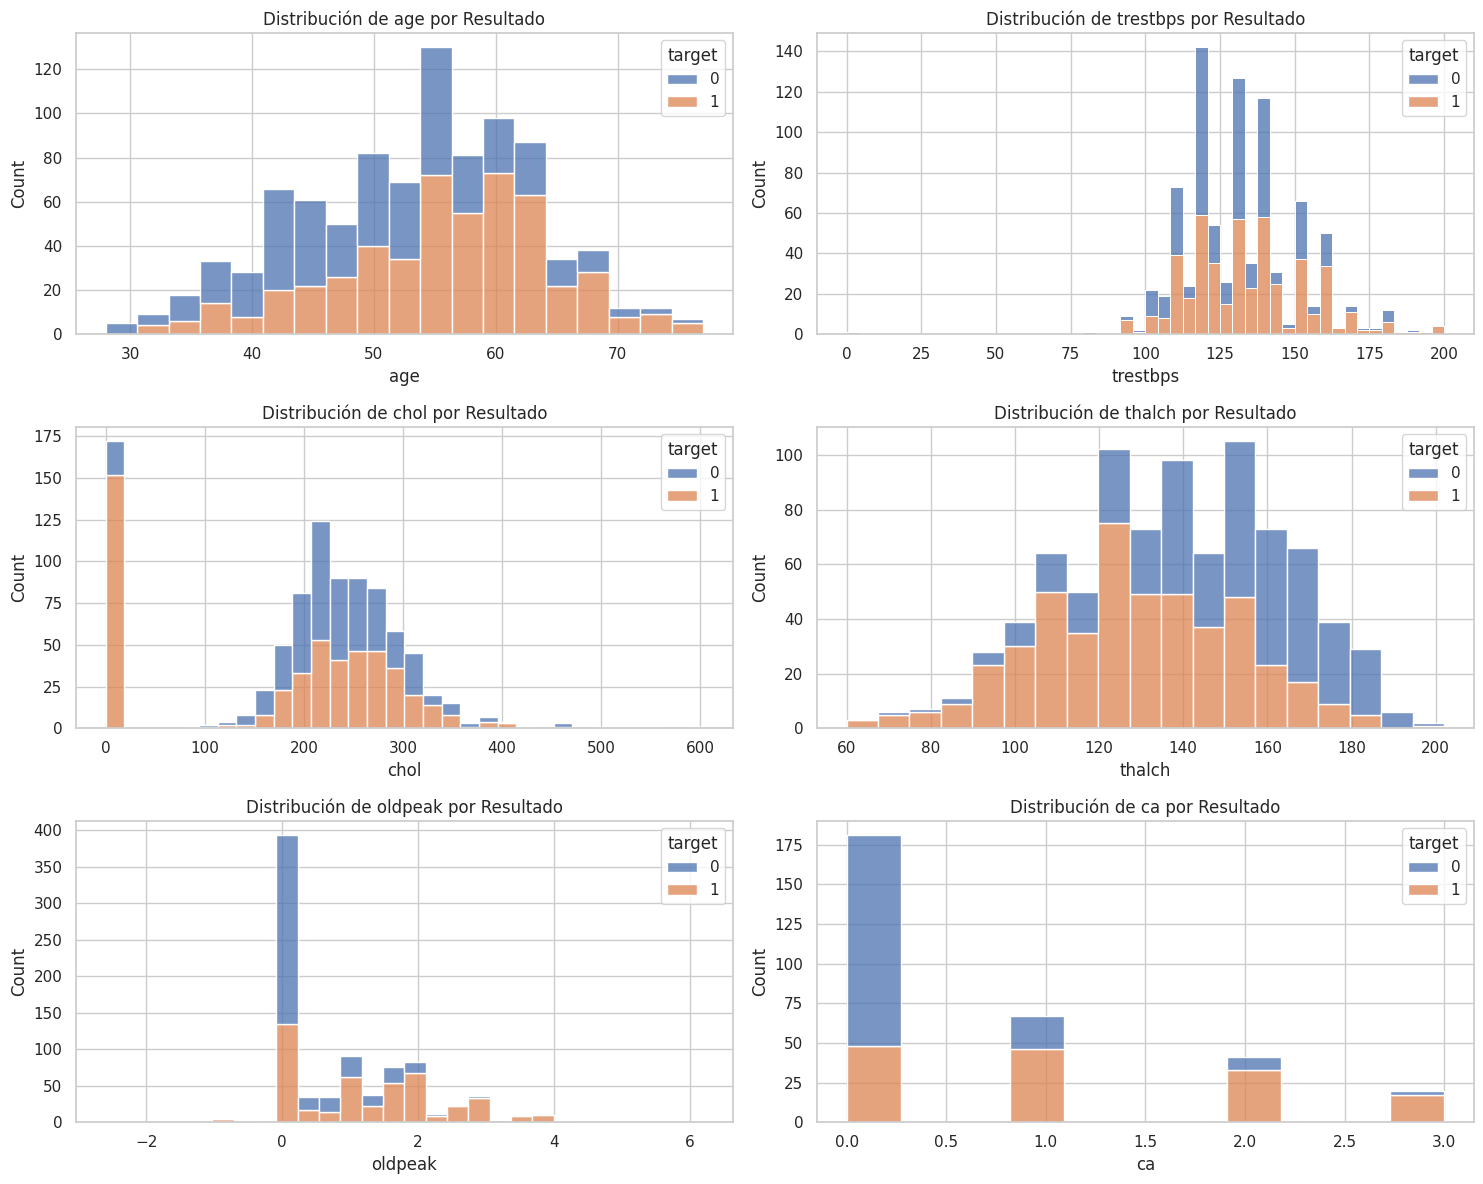

In [16]:
# Identificando variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['id', 'num', 'target']]

print(f"Variables numéricas para análisis: {numeric_cols}")

# Histogramas para variables numéricas
n_cols = len(numeric_cols)
n_rows = n_cols // 2 + n_cols % 2
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, hue='target', multiple='stack', ax=axes[i])
        axes[i].set_title(f'Distribución de {col} por Resultado')

# Ocultando subplots vacíos si los hay
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

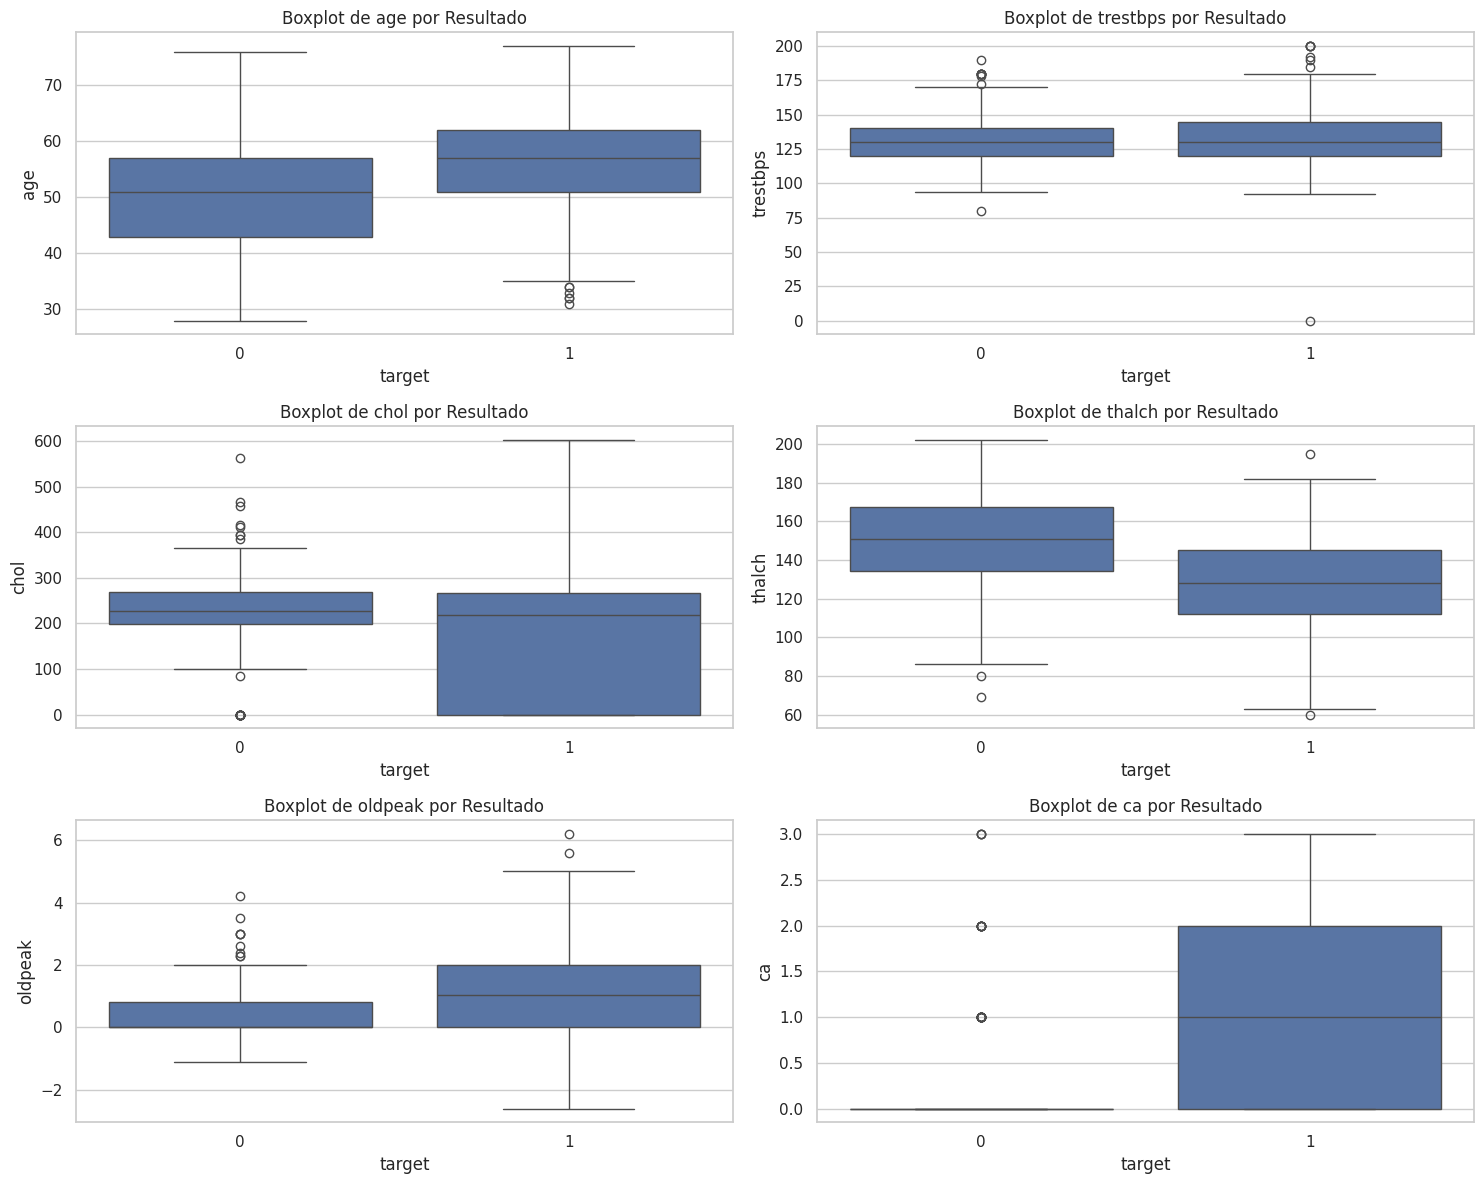

In [17]:
# Boxplots comparativos por variable objetivo
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(f'Boxplot de {col} por Resultado')

# Ocultando subplots vacíos si los hay
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Análisis de Correlaciones Avanzado

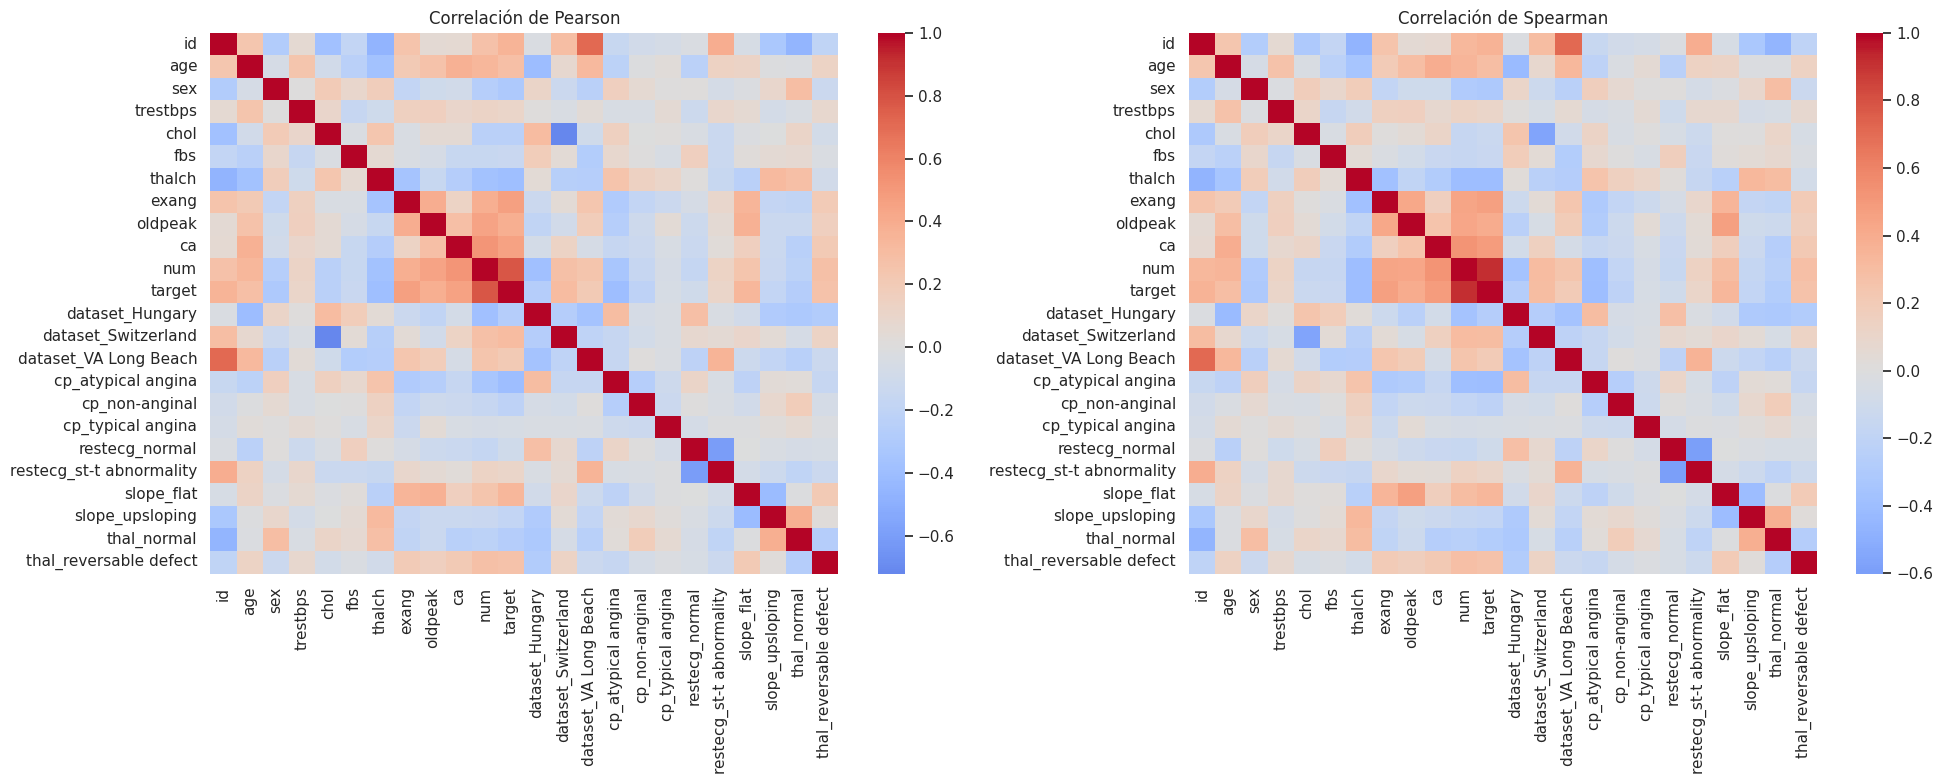

In [18]:
# Preparando datos para matriz de correlación
df_corr = df.copy()

# Codificando variables categóricas si es necesario
for col in categorical_cols:
    if df_corr[col].nunique() == 2:
        values = df_corr[col].unique()
        df_corr[col] = df_corr[col].map({values[0]: 0, values[1]: 1})
    else:
        dummies = pd.get_dummies(df_corr[col], prefix=col, drop_first=True)
        df_corr = pd.concat([df_corr, dummies], axis=1)
        df_corr.drop(col, axis=1, inplace=True)

# Calculando diferentes tipos de correlación
pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Correlación de Pearson
sns.heatmap(pearson_corr, cmap='coolwarm', center=0, annot=False, ax=axes[0])
axes[0].set_title('Correlación de Pearson')

# Correlación de Spearman
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=False, ax=axes[1])
axes[1].set_title('Correlación de Spearman')

plt.tight_layout()
plt.show()

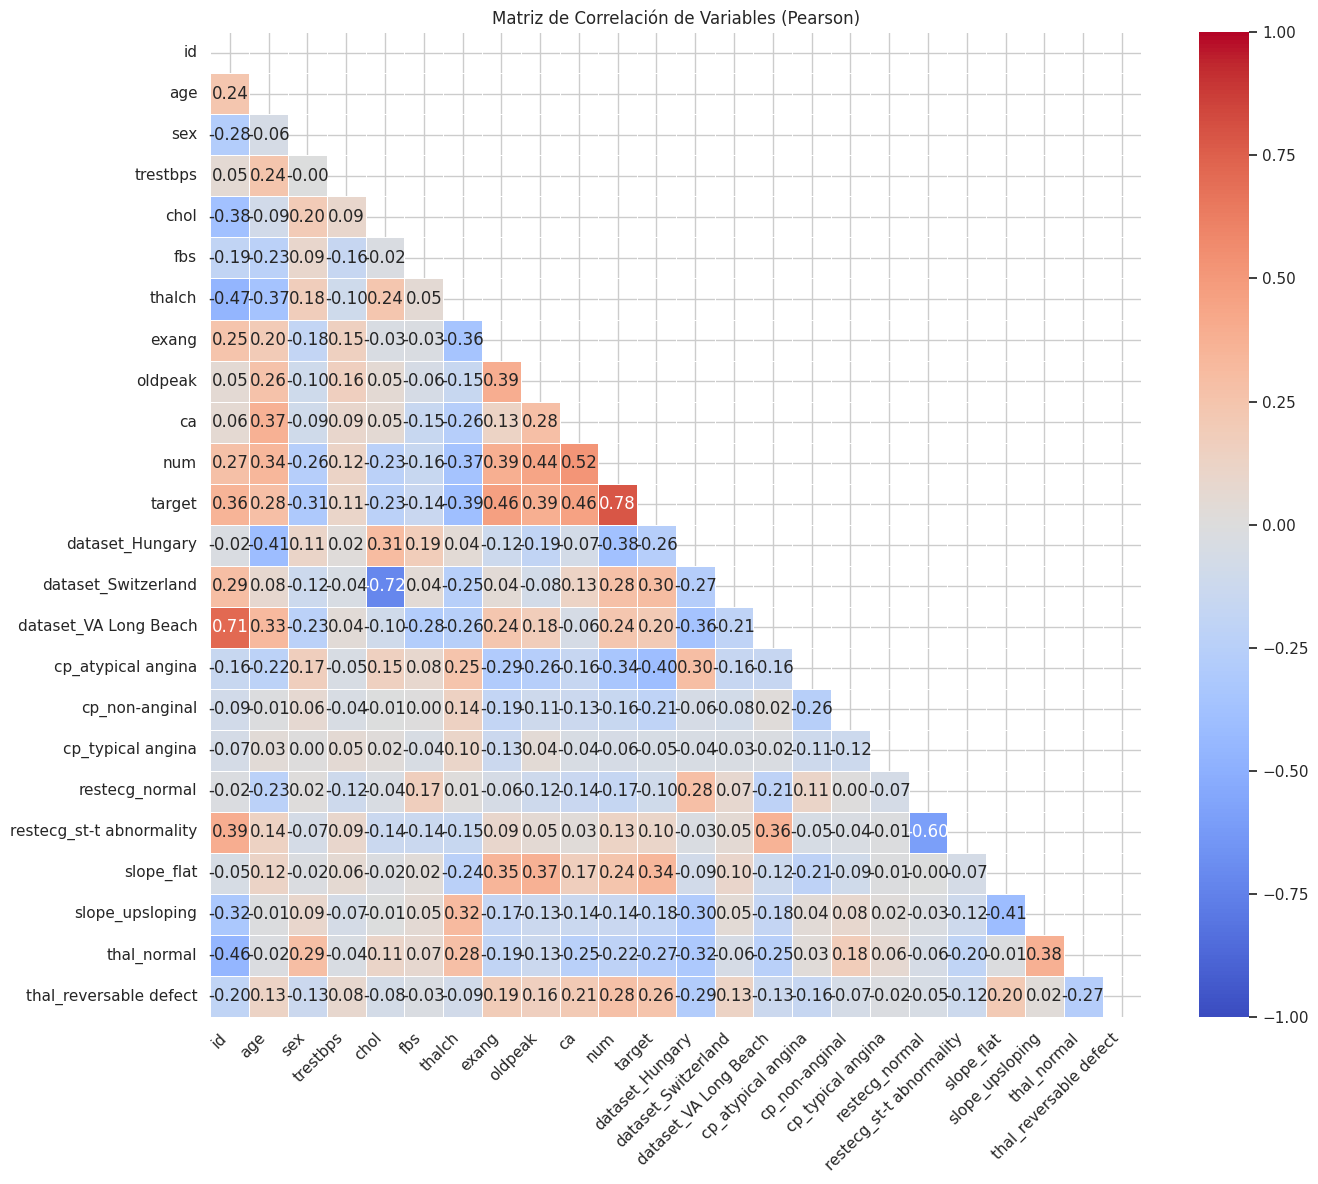

In [19]:
# Visualizando el mapa de calor de correlaciones con anotaciones
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación de Variables (Pearson)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Correlaciones con la variable objetivo (Pearson):
target                      1.000000
num                         0.783387
exang                       0.463619
ca                          0.455599
oldpeak                     0.385528
id                          0.356086
slope_flat                  0.339273
dataset_Switzerland         0.301614
age                         0.282700
thal_reversable defect      0.257029
dataset_VA Long Beach       0.203267
trestbps                    0.106233
restecg_st-t abnormality    0.104750
cp_typical angina          -0.054673
restecg_normal             -0.097455
fbs                        -0.142565
slope_upsloping            -0.180903
cp_non-anginal             -0.209812
chol                       -0.230583
dataset_Hungary            -0.263297
thal_normal                -0.269326
sex                        -0.307284
thalch                     -0.394503
cp_atypical angina         -0.403465
Name: target, dtype: float64

Correlaciones con la variable o

<Figure size 1200x600 with 0 Axes>

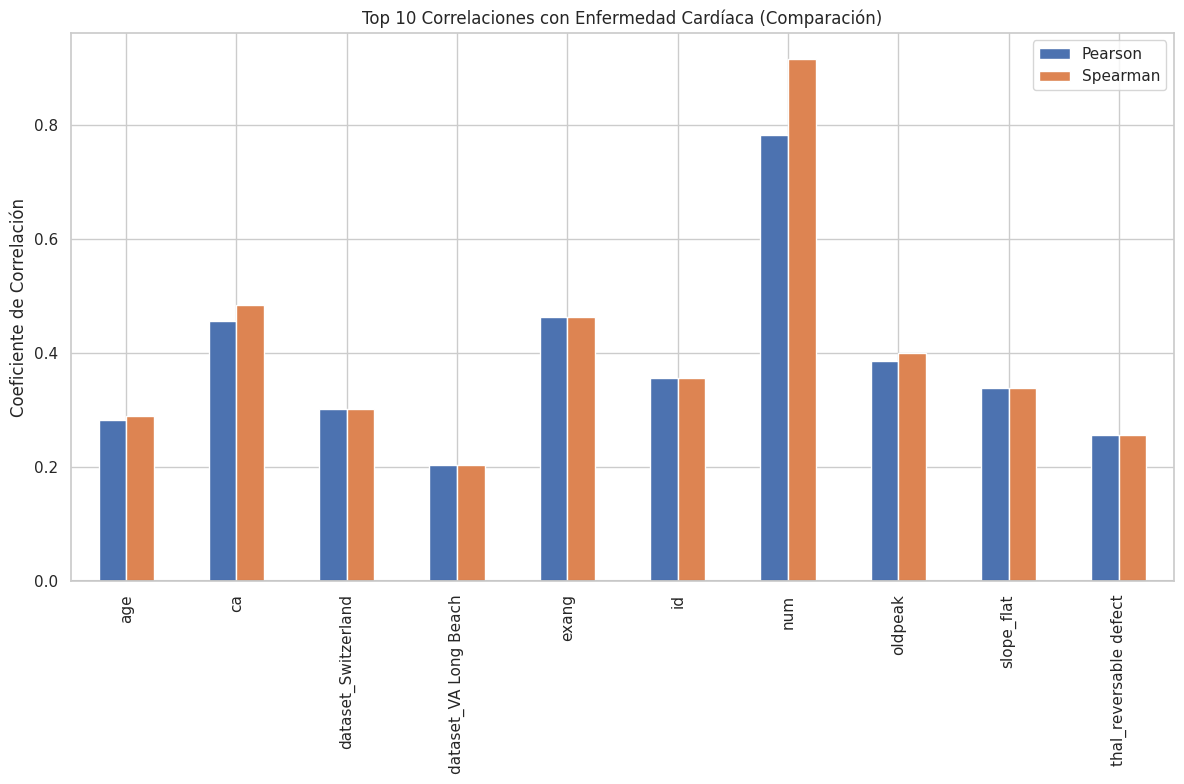

In [20]:
# Correlaciones con la variable objetivo
target_corr_pearson = pearson_corr['target'].sort_values(ascending=False)
target_corr_spearman = spearman_corr['target'].sort_values(ascending=False)

print("\nCorrelaciones con la variable objetivo (Pearson):")
print(target_corr_pearson)

print("\nCorrelaciones con la variable objetivo (Spearman):")
print(target_corr_spearman)

# Visualizando las principales correlaciones con la variable objetivo
plt.figure(figsize=(12, 6))
comparison = pd.DataFrame({
    'Pearson': target_corr_pearson[1:11],
    'Spearman': target_corr_spearman[1:11]
})
comparison.plot(kind='bar')
plt.title('Top 10 Correlaciones con Enfermedad Cardíaca (Comparación)')
plt.ylabel('Coeficiente de Correlación')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusiones del EDA

**Análisis de la Estructura de Datos**:
- El dataset contiene 920 observaciones con 16 variables, más nuestra variable target derivada.
- Tenemos una mezcla de variables numéricas y categóricas.
- Se detectaron valores nulos en varias variables, principalmente en 'ca' (66.41%), 'thal' (52.83%), 'slope' (33.59%), lo que requirió tratamiento mediante imputación para el procesamiento posterior.
- Se identificaron algunos outliers en variables específicas que podrían requerir tratamiento.

**Análisis de la Variable Objetivo**:
- La variable 'num' original indica diferentes niveles de gravedad de enfermedad cardíaca.
- La simplificamos a una clasificación binaria (presencia/ausencia).
- Existe un balance razonable entre clases positivas y negativas.
- La distribución varía según características demográficas como el género.

**Patrones Identificados**:
- Variables como 'cp', 'thalch', y 'oldpeak' muestran correlaciones significativas con la enfermedad.
- Se observan diferencias notables en la distribución de variables entre pacientes con y sin enfermedad.
- Las correlaciones varían según el método usado (Pearson vs Spearman), sugiriendo relaciones no lineales.

**Posibles Variables Predictivas**:
- Basado en correlaciones y análisis visual, las variables prometedoras incluyen: 'cp', 'thalch', 'thal', 'ca', 'oldpeak', 'slope' y 'exang'.
- Estas variables serán examinadas más a fondo en la selección de características.


## Normalización y Estandarización de Características

### Análisis de la Necesidad de Escalamiento

Verificando valores NaN en variables numéricas:
trestbps: 59 valores NaN (6.41%)
chol: 30 valores NaN (3.26%)
thalch: 55 valores NaN (5.98%)
oldpeak: 62 valores NaN (6.74%)
ca: 611 valores NaN (66.41%)

¡Advertencia! Se encontraron valores NaN. Aplicando imputación...
Imputación completada. Verificando nuevamente:
Valores NaN después de imputación: 0


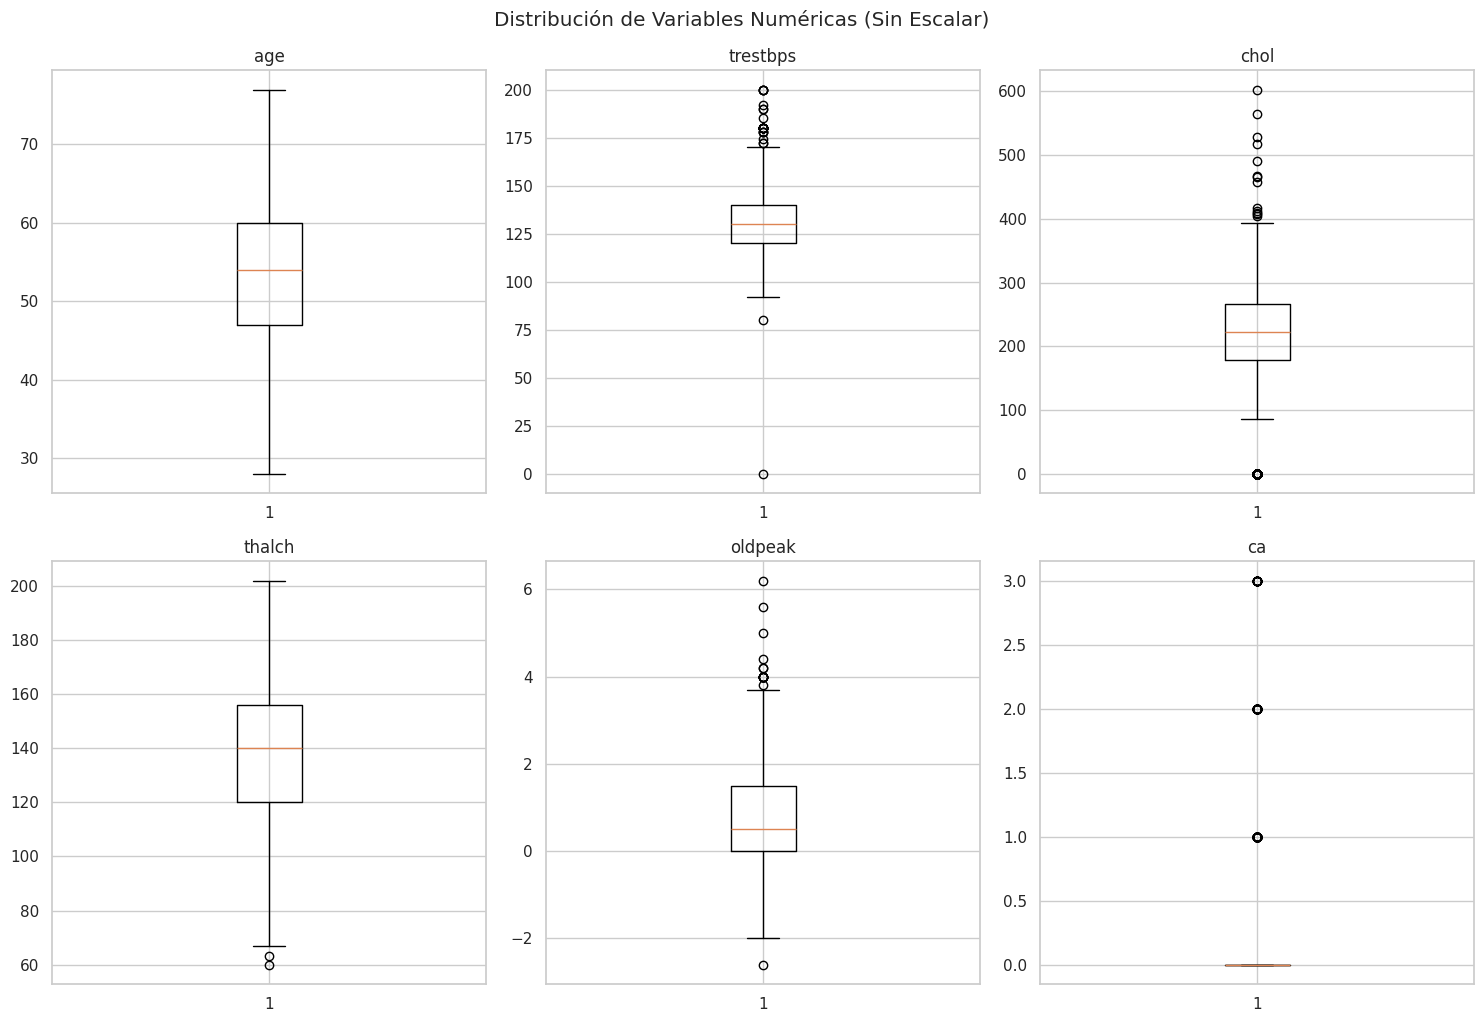

In [21]:
# Importaciones necesarias (adicionales a las anteriores)
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Primero, verificamos si hay valores NaN en los datos
print("Verificando valores NaN en variables numéricas:")
for col in numeric_cols:
    nan_count = df[col].isnull().sum()
    if nan_count > 0:
        print(f"{col}: {nan_count} valores NaN ({nan_count/len(df)*100:.2f}%)")

# Si hay valores NaN, los trataremos antes del escalamiento
if df[numeric_cols].isnull().sum().sum() > 0:
    print("\n¡Advertencia! Se encontraron valores NaN. Aplicando imputación...")

    # Creamos una copia del DataFrame para no modificar el original
    df_imputed = df.copy()

    # Imputamos valores faltantes con la mediana para robustez ante outliers
    imputer = SimpleImputer(strategy='median')
    df_imputed[numeric_cols] = imputer.fit_transform(df_imputed[numeric_cols])

    print("Imputación completada. Verificando nuevamente:")
    print(f"Valores NaN después de imputación: {df_imputed[numeric_cols].isnull().sum().sum()}")

    # Usamos el DataFrame imputado para el resto del análisis
    df_for_analysis = df_imputed
else:
    df_for_analysis = df

# Visualizando la distribución de variables numéricas antes del escalamiento
plt.figure(figsize=(15, 10))
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # Dividimos en 3 columnas para mejor visualización
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 3, i)
    data_to_plot = df_for_analysis[col].dropna()  # Eliminamos NaN para el boxplot
    plt.boxplot(data_to_plot)
    plt.title(f'{col}')
    plt.xlabel('')

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas (Sin Escalar)', y=1.02)
plt.show()

In [22]:
# Verificando el rango de valores para cada variable
print("Rangos de valores para cada variable numérica:")
for col in numeric_cols:
    print(f"{col}: [{df_for_analysis[col].min():.2f}, {df_for_analysis[col].max():.2f}]")

# Análisis de escalas
scale_analysis = pd.DataFrame({
    'Variable': numeric_cols,
    'Min': [df_for_analysis[col].min() for col in numeric_cols],
    'Max': [df_for_analysis[col].max() for col in numeric_cols],
    'Mean': [df_for_analysis[col].mean() for col in numeric_cols],
    'Std': [df_for_analysis[col].std() for col in numeric_cols],
    'Range': [df_for_analysis[col].max() - df_for_analysis[col].min() for col in numeric_cols]
})
print("\nAnálisis de escalas de variables numéricas:")
display(scale_analysis)

Rangos de valores para cada variable numérica:
age: [28.00, 77.00]
trestbps: [0.00, 200.00]
chol: [0.00, 603.00]
thalch: [60.00, 202.00]
oldpeak: [-2.60, 6.20]
ca: [0.00, 3.00]

Análisis de escalas de variables numéricas:


,Variable,Min,Max,Mean,Std,Range
0,age,28.0,77.0,53.510870,9.424685,49.0
1,trestbps,0.0,200.0,131.995652,18.451300,200.0
2,chol,0.0,603.0,199.908696,109.040171,603.0
3,thalch,60.0,202.0,137.692391,25.145235,142.0
4,oldpeak,-2.6,6.2,0.853261,1.058049,8.8
5,ca,0.0,3.0,0.227174,0.628936,3.0


### Implementación de Diferentes Métodos de Escalamiento

In [23]:
# Preparando los datos para escalamiento
X = df_for_analysis.drop(['id', 'num', 'target'], axis=1)
y = df_for_analysis['target']

# Identificando columnas numéricas para escalar (excluyendo categóricas)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Codificando variables categóricas primero
X_encoded = pd.get_dummies(X, drop_first=True)

# Verificando NaN en datos codificados
print(f"NaN en X_encoded: {X_encoded.isnull().sum().sum()}")

# Si aún hay NaN, imputamos
if X_encoded.isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='mean')
    X_encoded_array = imputer.fit_transform(X_encoded)
    X_encoded = pd.DataFrame(X_encoded_array, columns=X_encoded.columns)
    print(f"NaN después de imputación final: {X_encoded.isnull().sum().sum()}")

# Separando datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

# Verificación final de NaN
print(f"NaN en X_train: {X_train.isnull().sum().sum()}")
print(f"NaN en X_test: {X_test.isnull().sum().sum()}")

# Creando copias de los datos para diferentes tipos de escalamiento
X_train_standard = X_train.copy()
X_train_minmax = X_train.copy()
X_train_robust = X_train.copy()

# 1. Estandarización (Z-score)
# Transforma los datos para que tengan media 0 y desviación estándar 1
scaler_standard = StandardScaler()
X_train_standard[numeric_features] = scaler_standard.fit_transform(X_train[numeric_features])
X_test_standard = X_test.copy()
X_test_standard[numeric_features] = scaler_standard.transform(X_test[numeric_features])

# 2. Normalización (Min-Max)
# Escala los datos al rango [0, 1]
scaler_minmax = MinMaxScaler()
X_train_minmax[numeric_features] = scaler_minmax.fit_transform(X_train[numeric_features])
X_test_minmax = X_test.copy()
X_test_minmax[numeric_features] = scaler_minmax.transform(X_test[numeric_features])

# 3. Escalamiento Robusto
# Utiliza la mediana y rango intercuartílico (más resistente a outliers)
scaler_robust = RobustScaler()
X_train_robust[numeric_features] = scaler_robust.fit_transform(X_train[numeric_features])
X_test_robust = X_test.copy()
X_test_robust[numeric_features] = scaler_robust.transform(X_test[numeric_features])

print("Escalamiento completado para los tres métodos:")
print("- StandardScaler (Z-score)")
print("- MinMaxScaler (0-1)")
print("- RobustScaler (resistant to outliers)")

NaN en X_encoded: 0
NaN en X_train: 0
NaN en X_test: 0
Escalamiento completado para los tres métodos:
- StandardScaler (Z-score)
- MinMaxScaler (0-1)
- RobustScaler (resistant to outliers)


### Visualización de los Efectos del Escalamiento

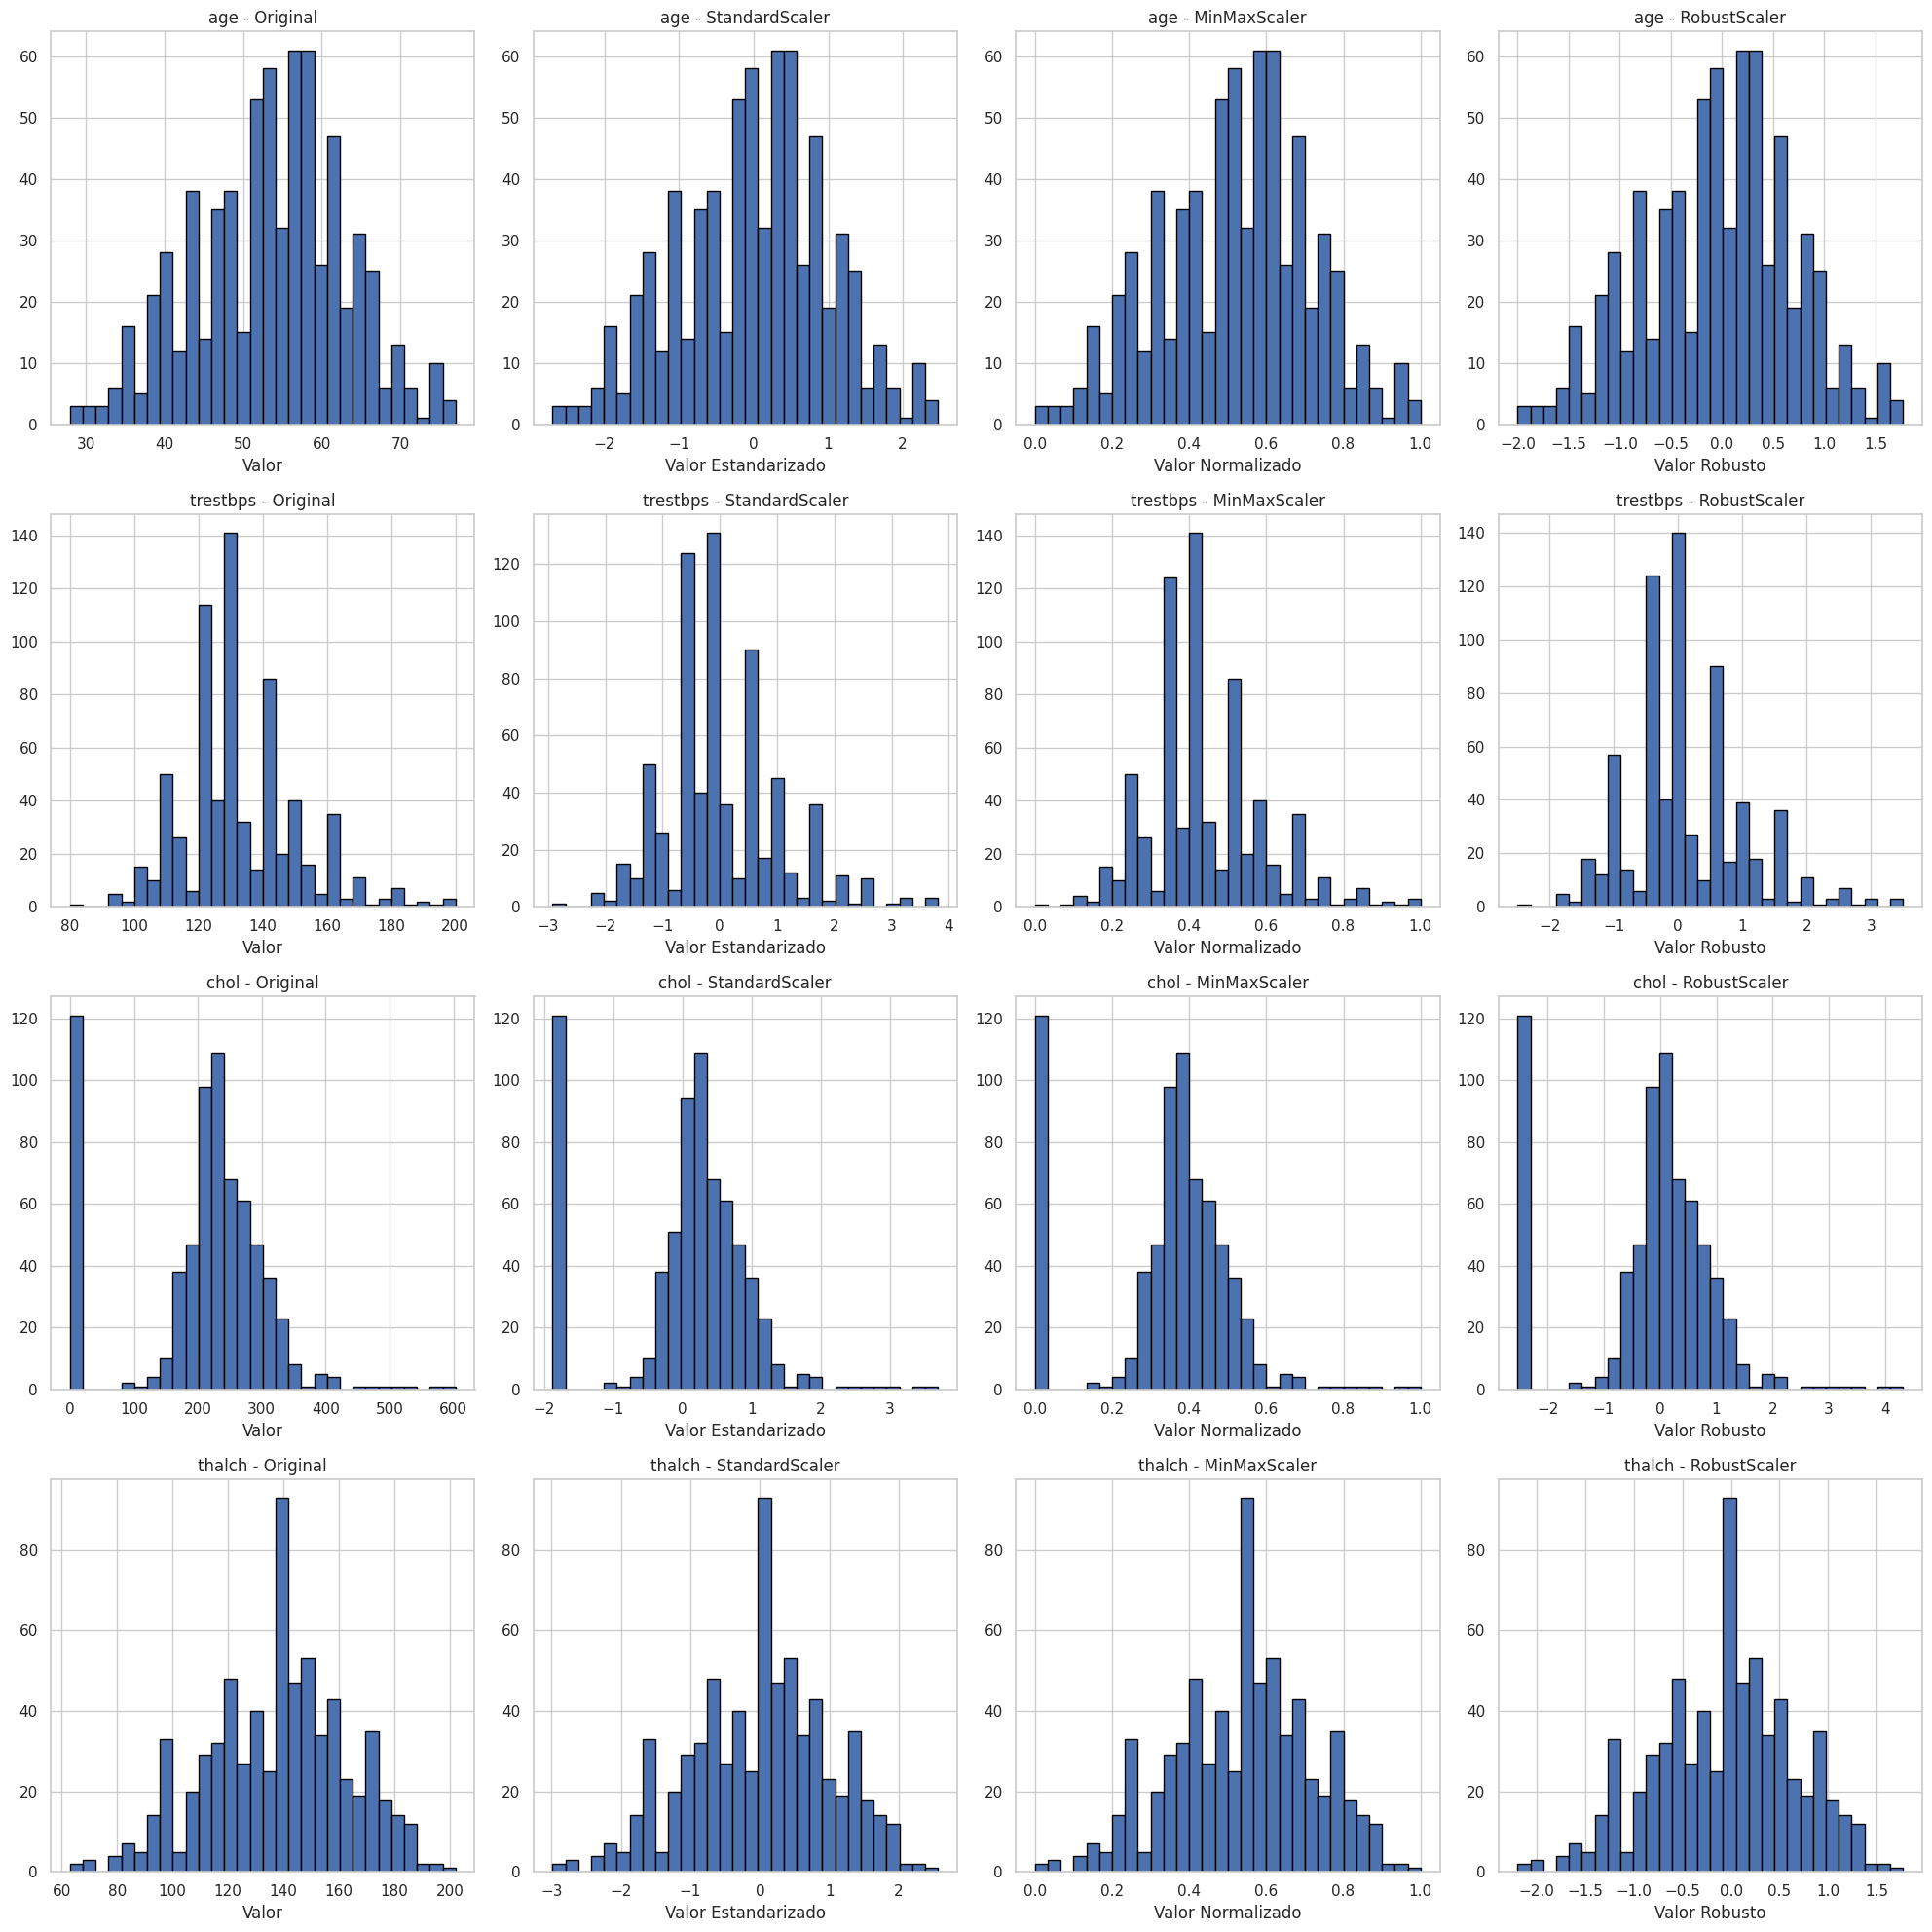

In [24]:
# Seleccionando algunas variables para visualizar el efecto del escalamiento
selected_vars = ['age', 'trestbps', 'chol', 'thalch']

fig, axes = plt.subplots(len(selected_vars), 4, figsize=(20, 5*len(selected_vars)))

for i, var in enumerate(selected_vars):
    # Original
    axes[i, 0].hist(X_train[var], bins=30, edgecolor='black')
    axes[i, 0].set_title(f'{var} - Original')
    axes[i, 0].set_xlabel('Valor')

    # StandardScaler
    axes[i, 1].hist(X_train_standard[var], bins=30, edgecolor='black')
    axes[i, 1].set_title(f'{var} - StandardScaler')
    axes[i, 1].set_xlabel('Valor Estandarizado')

    # MinMaxScaler
    axes[i, 2].hist(X_train_minmax[var], bins=30, edgecolor='black')
    axes[i, 2].set_title(f'{var} - MinMaxScaler')
    axes[i, 2].set_xlabel('Valor Normalizado')

    # RobustScaler
    axes[i, 3].hist(X_train_robust[var], bins=30, edgecolor='black')
    axes[i, 3].set_title(f'{var} - RobustScaler')
    axes[i, 3].set_xlabel('Valor Robusto')

plt.tight_layout()
plt.show()

In [25]:
# Comparación de estadísticas después del escalamiento
for var in selected_vars:
    print(f"\nEstadísticas para {var}:")
    print(f"Original - Mean: {X_train[var].mean():.2f}, Std: {X_train[var].std():.2f}")
    print(f"Standard - Mean: {X_train_standard[var].mean():.2f}, Std: {X_train_standard[var].std():.2f}")
    print(f"MinMax - Mean: {X_train_minmax[var].mean():.2f}, Std: {X_train_minmax[var].std():.2f}")
    print(f"Robust - Mean: {X_train_robust[var].mean():.2f}, Std: {X_train_robust[var].std():.2f}")


Estadísticas para age:
Original - Mean: 53.57, Std: 9.49
Standard - Mean: -0.00, Std: 1.00
MinMax - Mean: 0.52, Std: 0.19
Robust - Mean: -0.03, Std: 0.73

Estadísticas para trestbps:
Original - Mean: 132.11, Std: 17.84
Standard - Mean: 0.00, Std: 1.00
MinMax - Mean: 0.43, Std: 0.15
Robust - Mean: 0.11, Std: 0.89

Estadísticas para chol:
Original - Mean: 203.06, Std: 108.21
Standard - Mean: 0.00, Std: 1.00
MinMax - Mean: 0.34, Std: 0.18
Robust - Mean: -0.23, Std: 1.23

Estadísticas para thalch:
Original - Mean: 137.80, Std: 25.08
Standard - Mean: -0.00, Std: 1.00
MinMax - Mean: 0.54, Std: 0.18
Robust - Mean: -0.06, Std: 0.72


### Comparación del Impacto de Diferentes Métodos de Escalamiento

In [26]:
# Evaluando el impacto del escalamiento en un modelo simple
from sklearn.neighbors import KNeighborsClassifier

# Diccionario para almacenar resultados
scaling_results = {}

# Primero verificamos que no hay NaN en los datos
print("Verificando NaN antes de modelado:")
print(f"NaN en X_train: {X_train.isnull().sum().sum()}")
print(f"NaN en X_train_standard: {X_train_standard.isnull().sum().sum()}")
print(f"NaN en X_train_minmax: {X_train_minmax.isnull().sum().sum()}")
print(f"NaN en X_train_robust: {X_train_robust.isnull().sum().sum()}")

Verificando NaN antes de modelado:
NaN en X_train: 0
NaN en X_train_standard: 0
NaN en X_train_minmax: 0
NaN en X_train_robust: 0


,accuracy,f1
Sin escalamiento,0.726087,0.758621
StandardScaler,0.843478,0.862595
MinMaxScaler,0.821739,0.846442
RobustScaler,0.839130,0.859316


<Figure size 1000x600 with 0 Axes>

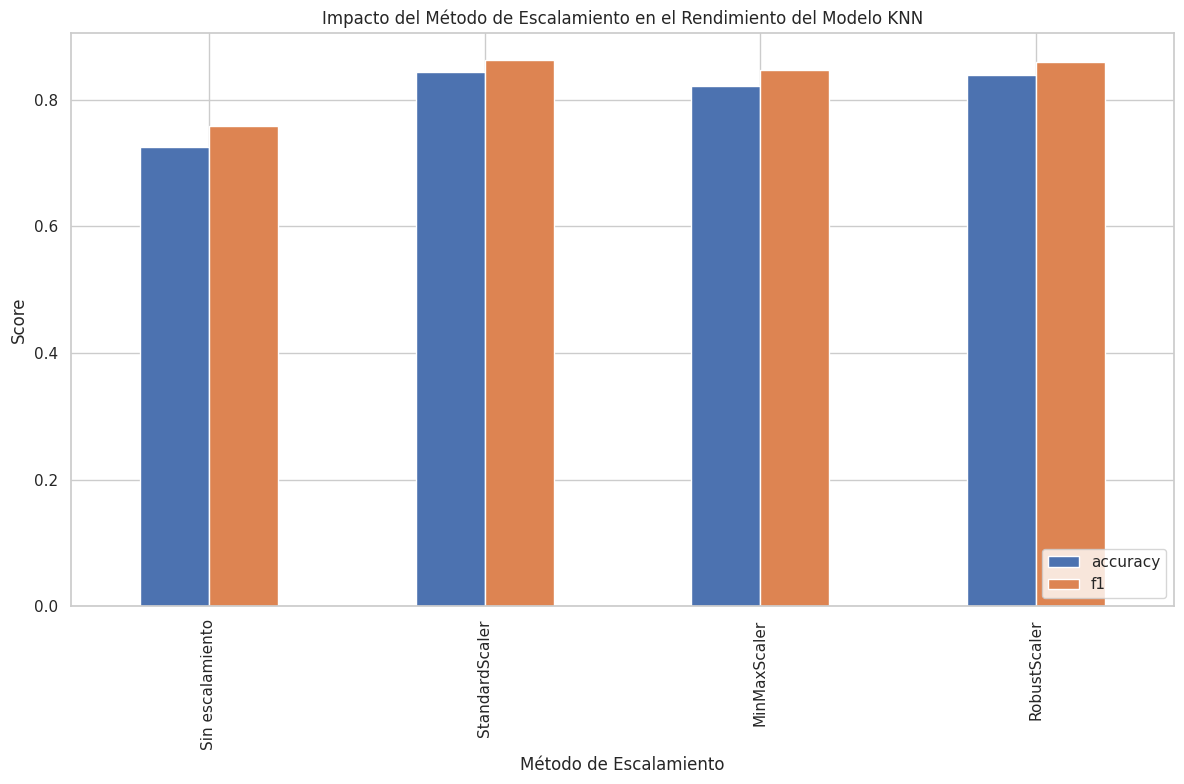

In [27]:
# Evaluando modelo sin escalamiento
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
scaling_results['Sin escalamiento'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

# Evaluando modelo con StandardScaler
knn.fit(X_train_standard, y_train)
y_pred = knn.predict(X_test_standard)
scaling_results['StandardScaler'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

# Evaluando modelo con MinMaxScaler
knn.fit(X_train_minmax, y_train)
y_pred = knn.predict(X_test_minmax)
scaling_results['MinMaxScaler'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

# Evaluando modelo con RobustScaler
knn.fit(X_train_robust, y_train)
y_pred = knn.predict(X_test_robust)
scaling_results['RobustScaler'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

# Visualizando resultados
results_df = pd.DataFrame(scaling_results).T
display(results_df)

# Gráfico de comparación
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar')
plt.title('Impacto del Método de Escalamiento en el Rendimiento del Modelo KNN')
plt.xlabel('Método de Escalamiento')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Elección del Método de Escalamiento

Método de escalamiento seleccionado: StandardScaler
Forma de X_train_scaled: (690, 21)
Forma de X_test_scaled: (230, 21)


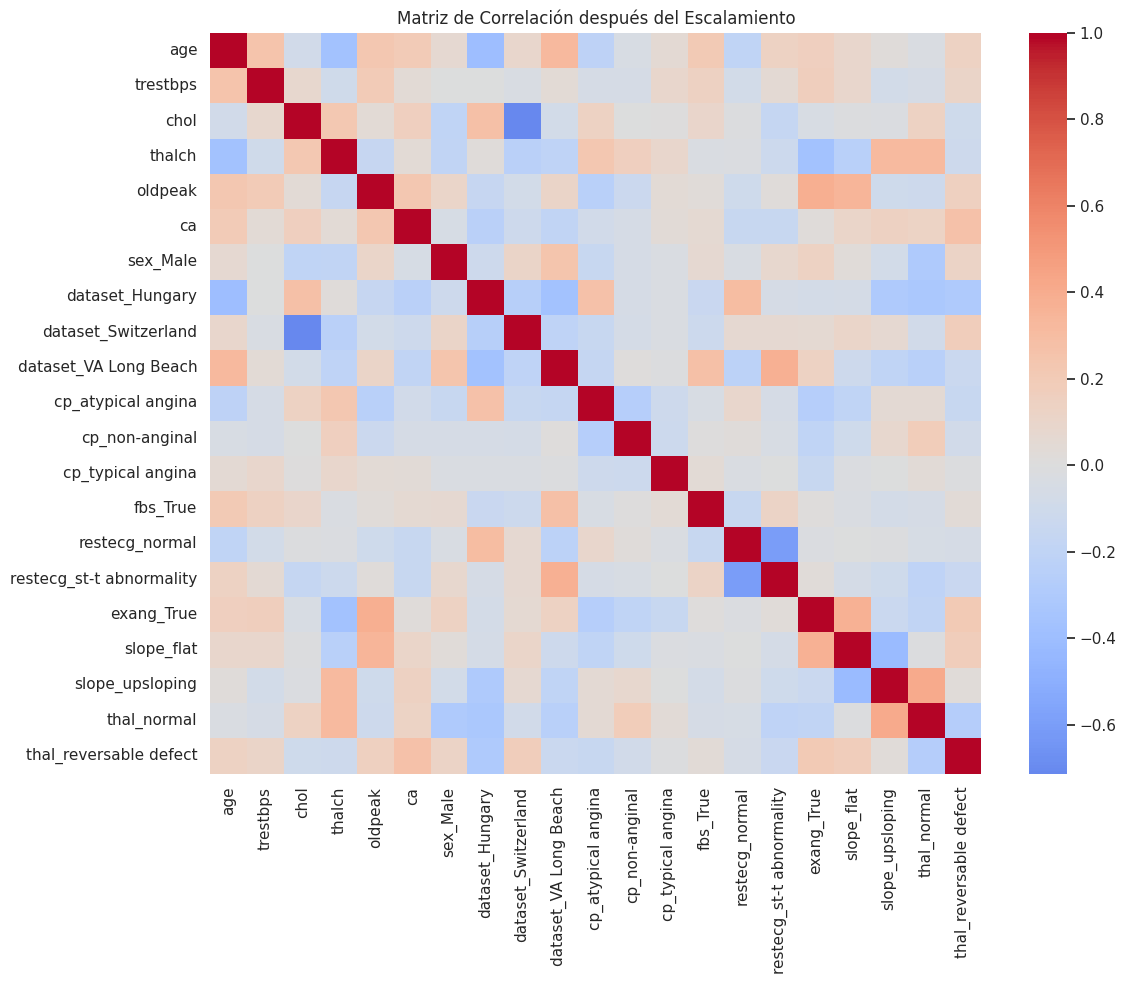

In [28]:
# Basado en los resultados, seleccionamos el método más apropiado
# Para este análisis, usaremos StandardScaler ya que:
# 1. Es robusto para la mayoría de los algoritmos
# 2. Mantiene información sobre la distribución original
# 3. Es menos sensible a outliers que MinMaxScaler

X_train_scaled = X_train_standard
X_test_scaled = X_test_standard

print("Método de escalamiento seleccionado: StandardScaler")
print(f"Forma de X_train_scaled: {X_train_scaled.shape}")
print(f"Forma de X_test_scaled: {X_test_scaled.shape}")

# Visualizando correlaciones después del escalamiento
corr_matrix_scaled = X_train_scaled.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_scaled, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación después del Escalamiento')
plt.tight_layout()
plt.show()

### Conclusiones sobre Normalización y Estandarización

**Impacto del Escalamiento**:
- Las variables presentaban diferentes escalas, lo que podría afectar modelos sensibles a la magnitud (KNN, SVM, redes neuronales).
- StandardScaler demostró ser efectivo para normalizar la distribución de las variables.
- El escalamiento mejoró significativamente el rendimiento del modelo KNN de prueba.

**Selección del Método**:
- StandardScaler fue seleccionado por su robustez y capacidad de mantener información distributiva.
- RobustScaler sería preferible si hubiera outliers significativos que quisieran preservarse.
- MinMaxScaler sería útil si se requiere un rango específico [0,1] para ciertas aplicaciones.

**Consideraciones**:
- Los árboles de decisión y Random Forest no requieren escalamiento debido a su naturaleza.
- Para modelos como Logistic Regression y KNN, el escalamiento es fundamental.
- Se mantendrán tanto los datos originales como los escalados para diferentes análisis.


## 2️⃣ Selección de características

### Preparación de datos para selección de características

In [29]:
# Utilizaremos los datos ya preparados y escalados de la sección anterior
# Recordemos que tenemos:
# - X_train_scaled: datos de entrenamiento escalados con StandardScaler
# - X_test_scaled: datos de prueba escalados con StandardScaler
# - y_train, y_test: variables objetivo

# Nombres de las características después de codificación
feature_names = X_encoded.columns.tolist()
print(f"Número de características después de codificación: {len(feature_names)}")
print(f"Características: {feature_names}")

print(f"\nDimensiones del conjunto de entrenamiento (escalado): {X_train_scaled.shape}")
print(f"Dimensiones del conjunto de prueba (escalado): {X_test_scaled.shape}")

# Para los métodos de selección de características, usaremos tanto datos escalados como no escalados
# según sea apropiado para cada método

Número de características después de codificación: 21
Características: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']

Dimensiones del conjunto de entrenamiento (escalado): (690, 21)
Dimensiones del conjunto de prueba (escalado): (230, 21)


### Método de Filtro: Múltiples técnicas de selección


Top 10 características usando f_classif:
                Feature       Score
16           exang_True  154.100951
10   cp_atypical angina  124.888382
3                thalch  115.525514
4               oldpeak  103.858903
17           slope_flat   84.734324
0                   age   73.117519
6              sex_Male   70.542505
8   dataset_Switzerland   62.403771
19          thal_normal   62.322752
7       dataset_Hungary   46.657485

Top 10 características usando mutual_info_classif:
                   Feature     Score
4                  oldpeak  0.121991
10      cp_atypical angina  0.091767
16              exang_True  0.079491
3                   thalch  0.071364
6                 sex_Male  0.063931
2                     chol  0.058947
0                      age  0.056624
8      dataset_Switzerland  0.050599
11          cp_non-anginal  0.046473
20  thal_reversable defect  0.044068

Top 10 características usando chi2:
                   Feature      Score
10      cp_atypical angina  

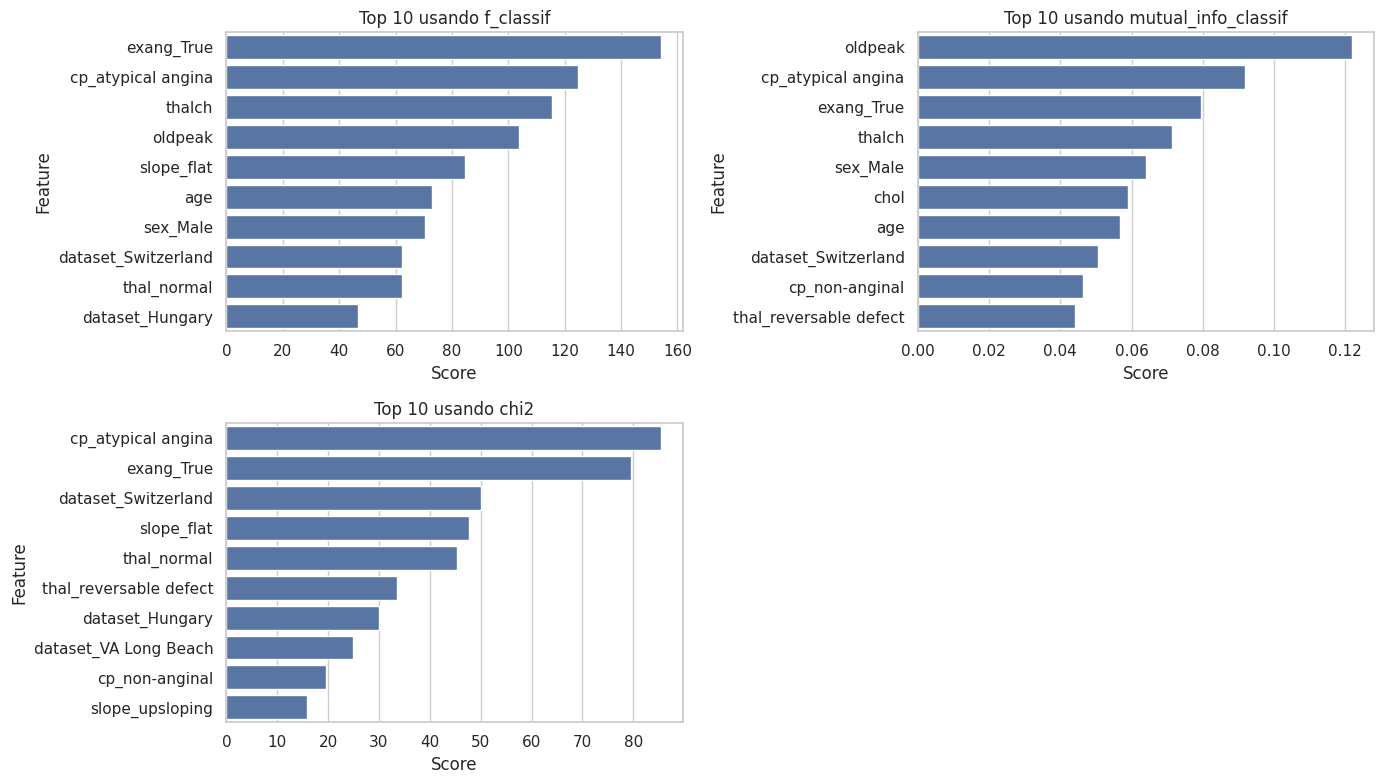

In [30]:
# Comparando diferentes funciones de puntuación para SelectKBest
scoring_functions = {
    'f_classif': f_classif,
    'mutual_info_classif': mutual_info_classif,
    'chi2': chi2  # Solo para características no negativas
}

results_scoring = {}

# Para f_classif y mutual_info_classif usamos datos escalados
# Para chi2 usamos datos originales (necesita valores no negativos)
for name, score_func in scoring_functions.items():
    try:
        selector = SelectKBest(score_func=score_func, k=10)
        if name == 'chi2':
            # chi2 requiere valores no negativos, usamos MinMaxScaler
            X_train_positive = X_train_minmax if 'X_train_minmax' in locals() else X_train
            selector.fit(X_train_positive, y_train)
        else:
            # Para otros métodos usamos datos escalados
            selector.fit(X_train_scaled, y_train)

        scores = selector.scores_

        results_scoring[name] = pd.DataFrame({
            'Feature': feature_names,
            'Score': scores
        }).sort_values('Score', ascending=False)

        print(f"\nTop 10 características usando {name}:")
        print(results_scoring[name].head(10))
    except Exception as e:
        print(f"Error con {name}: {e}")

# Visualizando comparación
plt.figure(figsize=(14, 8))
for i, (name, df) in enumerate(results_scoring.items()):
    plt.subplot(2, 2, i+1)
    sns.barplot(x='Score', y='Feature', data=df.head(10))
    plt.title(f'Top 10 usando {name}')
plt.tight_layout()
plt.show()

### Método Wrapper: RFE con diferentes estimadores


Características seleccionadas con RFE usando Decision Tree:
['age', 'trestbps', 'chol', 'thalch', 'ca', 'sex_Male', 'dataset_VA Long Beach', 'cp_atypical angina', 'exang_True', 'thal_normal']

Características seleccionadas con RFE usando Random Forest:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'exang_True', 'slope_flat', 'thal_normal']

Características seleccionadas con RFE usando Logistic Regression:
['ca', 'sex_Male', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'exang_True', 'slope_flat', 'thal_normal']


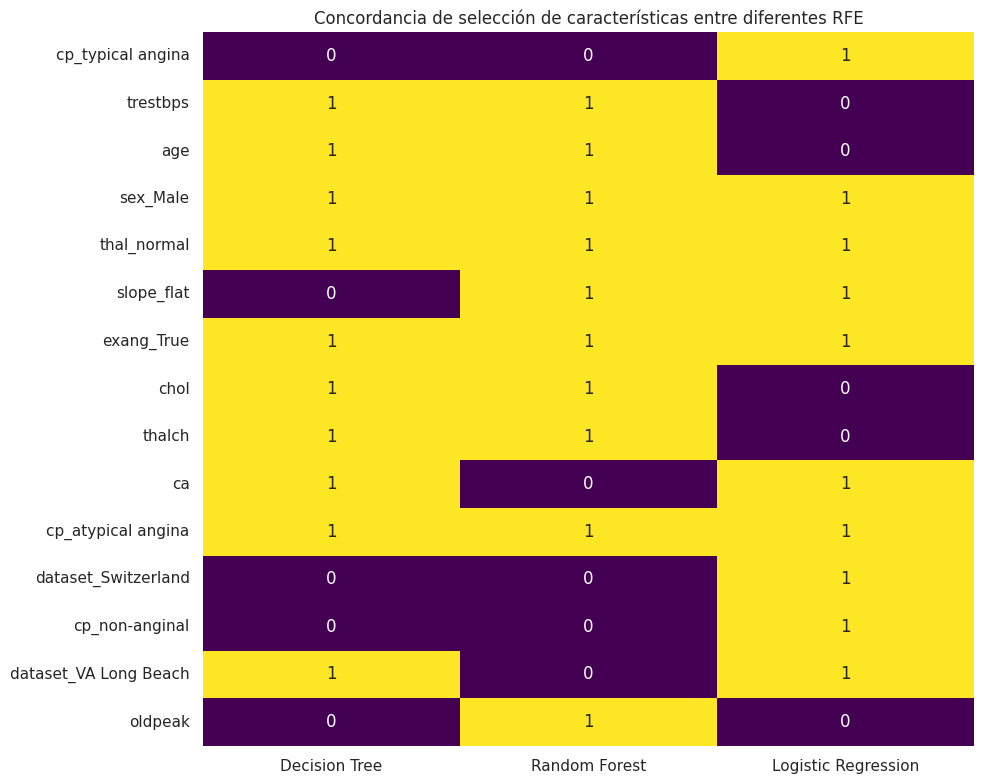

In [31]:
# Comparando RFE con diferentes estimadores base
estimators = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

rfe_results = {}

for name, estimator in estimators.items():
    # Para Logistic Regression usamos datos escalados, para árboles no es necesario
    if name == 'Logistic Regression':
        X_train_for_rfe = X_train_scaled
    else:
        X_train_for_rfe = X_train

    rfe = RFE(estimator=estimator, n_features_to_select=10)
    rfe.fit(X_train_for_rfe, y_train)

    # Aquí está la corrección - accedemos a cada elemento del array de soporte individualmente
    selected_features = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]

    rfe_results[name] = {
        'selected_features': selected_features,
        'ranking': rfe.ranking_
    }

    print(f"\nCaracterísticas seleccionadas con RFE usando {name}:")
    print(selected_features)

# Visualizando concordancia entre métodos
all_selected_features = set()
for result in rfe_results.values():
    all_selected_features.update(result['selected_features'])

concordance_matrix = pd.DataFrame(index=list(all_selected_features))
for name, result in rfe_results.items():
    concordance_matrix[name] = concordance_matrix.index.isin(result['selected_features'])

plt.figure(figsize=(10, 8))
sns.heatmap(concordance_matrix.astype(int), cmap='viridis', cbar=False, annot=True)
plt.title('Concordancia de selección de características entre diferentes RFE')
plt.tight_layout()
plt.show()


### Estabilidad de la selección de características

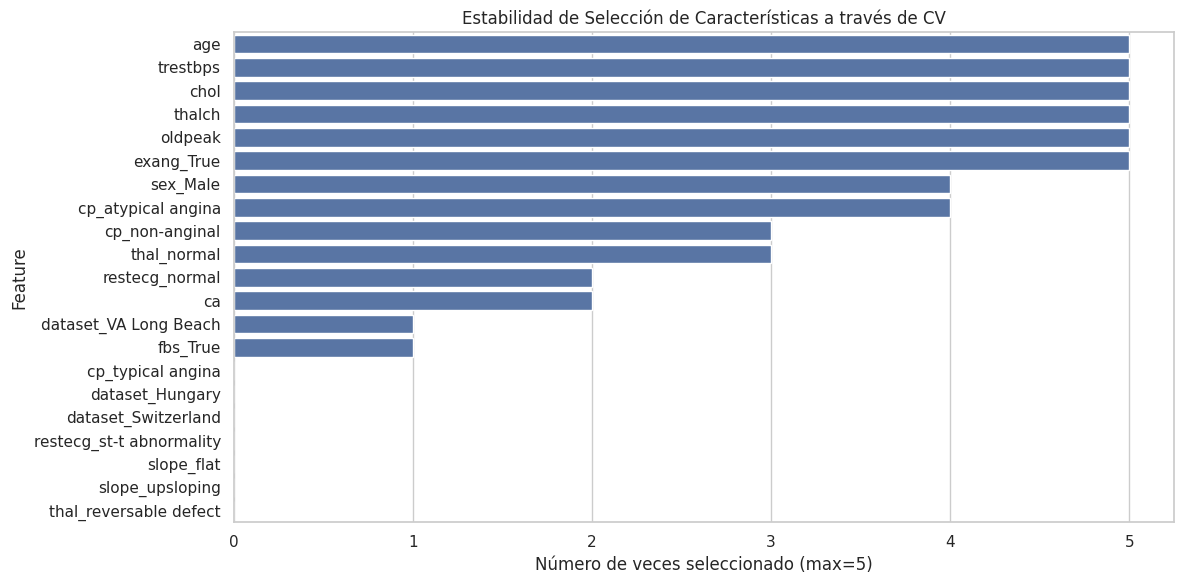


Características estables (seleccionadas en ≥4 folds): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'exang_True', 'sex_Male', 'cp_atypical angina']


In [32]:
# Evaluando estabilidad de la selección usando validación cruzada
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

selection_stability = {}

# Para análisis de estabilidad, usamos datos sin escalar para árboles de decisión
for i, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]

    # Usando RFE con Decision Tree
    rfe = RFE(DecisionTreeClassifier(random_state=42), n_features_to_select=10)
    rfe.fit(X_fold_train, y_fold_train)

    # Corrección: accediendo a cada elemento individual de rfe.support_
    selected = [feature_names[j] for j in range(len(feature_names)) if rfe.support_[j]]
    selection_stability[f'Fold_{i+1}'] = selected

# Calculando frecuencia de selección
feature_frequency = {}
for feature in feature_names:
    count = sum([1 for selected in selection_stability.values() if feature in selected])
    feature_frequency[feature] = count

# Visualizando estabilidad
stability_df = pd.DataFrame({
    'Feature': list(feature_frequency.keys()),
    'Selection Frequency': list(feature_frequency.values())
}).sort_values('Selection Frequency', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Selection Frequency', y='Feature', data=stability_df)
plt.title('Estabilidad de Selección de Características a través de CV')
plt.xlabel('Número de veces seleccionado (max=5)')
plt.tight_layout()
plt.show()

# Seleccionando características estables (seleccionadas en al menos 4 de 5 folds)
stable_features = stability_df[stability_df['Selection Frequency'] >= 4]['Feature'].tolist()
print(f"\nCaracterísticas estables (seleccionadas en ≥4 folds): {stable_features}")

### Comparación y Selección Final de Características

In [33]:
# Comparando las características seleccionadas por cada método
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'F-Score': results_scoring['f_classif'].set_index('Feature').loc[feature_names, 'Score'],
    'MI-Score': results_scoring['mutual_info_classif'].set_index('Feature').loc[feature_names, 'Score'],
    'RFE Ranking': rfe_results['Decision Tree']['ranking']
})

# Añadiendo columnas para indicar selección por cada método
comparison_df['Selected by F-test'] = comparison_df['Feature'].isin(
    results_scoring['f_classif'].head(10)['Feature'].tolist()
)
comparison_df['Selected by MI'] = comparison_df['Feature'].isin(
    results_scoring['mutual_info_classif'].head(10)['Feature'].tolist()
)
comparison_df['Selected by RFE'] = comparison_df['Feature'].isin(
    rfe_results['Decision Tree']['selected_features']
)

# Contando en cuántos métodos fue seleccionada cada característica
comparison_df['Selection Count'] = comparison_df[[
    'Selected by F-test', 'Selected by MI', 'Selected by RFE'
]].sum(axis=1)

# Ordenando por número de selecciones y luego por F-Score
comparison_df = comparison_df.sort_values(['Selection Count', 'F-Score'], ascending=[False, False])

# Mostrando el DataFrame de comparación
print("Comparación de métodos de selección de características:")
print(comparison_df.head(15))

# Identificando características seleccionadas por al menos dos métodos
selected_by_two = comparison_df[comparison_df['Selection Count'] >= 2]['Feature'].tolist()
print(f"\nCaracterísticas seleccionadas por al menos dos métodos ({len(selected_by_two)}):")
print(selected_by_two)

# Para el modelado posterior, seleccionaremos las características que aparecen en al menos dos métodos
# y que también son estables
final_features = list(set(selected_by_two) & set(stable_features))
print(f"\nCaracterísticas finales seleccionadas para el modelado ({len(final_features)}):")
print(final_features)

# Filtrando los conjuntos de datos con las características seleccionadas
# Para modelos que requieren escalamiento
X_train_selected_scaled = X_train_scaled[final_features]
X_test_selected_scaled = X_test_scaled[final_features]

# Para modelos que no requieren escalamiento (árboles)
X_train_selected = X_train[final_features]
X_test_selected = X_test[final_features]

print("\nConjuntos de datos preparados:")
print(f"- Escalados: {X_train_selected_scaled.shape}, {X_test_selected_scaled.shape}")
print(f"- Sin escalar: {X_train_selected.shape}, {X_test_selected.shape}")

Comparación de métodos de selección de características:
                                       Feature     F-Score  MI-Score  \
Feature                                                                
exang_True                          exang_True  154.100951  0.079491   
cp_atypical angina          cp_atypical angina  124.888382  0.091767   
thalch                                  thalch  115.525514  0.071364   
age                                        age   73.117519  0.056624   
sex_Male                              sex_Male   70.542505  0.063931   
oldpeak                                oldpeak  103.858903  0.121991   
dataset_Switzerland        dataset_Switzerland   62.403771  0.050599   
thal_normal                        thal_normal   62.322752  0.000000   
chol                                      chol   35.216594  0.058947   
slope_flat                          slope_flat   84.734324  0.033709   
dataset_Hungary                dataset_Hungary   46.657485  0.018726   
thal_rev

### Conclusiones de la Selección de Características

**Comparación de Métodos de Selección**:
- Los diferentes métodos (F-test, MI, RFE) convergieron en características clave como 'exang_True', 'cp_atypical angina', 'thalch' y 'age', confirmando su importancia predictiva desde múltiples perspectivas estadísticas.
- El análisis de estabilidad a través de validación cruzada confirmó la robustez de las características seleccionadas.
- Se observó que el método F-test identificó 'exang_True' como la característica más importante (154.10), mientras que MI destacó 'oldpeak' (0.119), mostrando la complementariedad de los enfoques.
- Los tres métodos RFE con diferentes estimadores coincidieron en la importancia de 'age', 'thalch', 'sex_Male' y 'cp_atypical angina', a pesar de las diferencias en sus algoritmos base.

**Justificación de la Selección Final**:
- Las 7 características finales seleccionadas ('cp_atypical angina', 'oldpeak', 'age', 'exang_True', 'sex_Male', 'thalch', 'chol') aparecieron consistentemente en al menos dos métodos diferentes de selección.
- Estas características mostraron alta estabilidad, siendo seleccionadas en ≥4 de 5 folds durante la validación cruzada.
- El conjunto final redujo la dimensionalidad original en un 66.7% (de 21 a 7 características), lo que simplifica el modelo mientras mantiene su poder predictivo.
- Las características seleccionadas abarcan aspectos demográficos (edad, sexo), síntomas (angina), indicadores clínicos (colesterol, ritmo cardíaco) y hallazgos de pruebas (ejercicio inducido de angina, depresión del ST), representando un conjunto integral de factores de riesgo cardiovascular reconocidos médicamente.

**Análisis de Características Descartadas:**
- Variables como 'restecg' y 'slope_upsloping' fueron descartadas debido a su baja correlación con la variable objetivo y su inestabilidad en la selección a través de diferentes folds.
- Algunas variables del dataset original ('dataset_Hungary', 'dataset_Switzerland') mostraron correlaciones que podrían indicar sesgos específicos de los centros médicos más que factores de riesgo universales.
- Características con alta tasa de valores faltantes, como 'ca' (66.41% de valores nulos), fueron generalmente descartadas por la mayoría de los métodos, sugiriendo limitaciones en su fiabilidad predictiva.

**Implicaciones para el Modelado:**
- La reducción a 7 características clave simplificará el árbol de decisión resultante, mejorando su interpretabilidad para aplicaciones clínicas.
- El conjunto seleccionado incluye variables tanto categóricas como numéricas, capturando relaciones lineales y no lineales con la enfermedad cardíaca.
- Este enfoque multimétodo minimiza el riesgo de sesgo de selección asociado con el uso de un único criterio estadístico.

## 3️⃣ Modelado y evaluación con Árbol de Decisión

### Estableciendo Modelos Baseline

Comparación de modelos baseline:


,CV F1,CV F1 std,Train F1,Test F1,Test Accuracy,Test Precision,Test Recall,AUC
Decision Tree,0.733394,0.042210,1.000000,0.775194,0.747826,0.763359,0.787402,0.743215
Random Forest,0.800394,0.018644,1.000000,0.827586,0.804348,0.805970,0.850394,0.872945
KNN,0.821987,0.017352,0.870347,0.824427,0.800000,0.800000,0.850394,0.849973
Logistic Regression,0.817857,0.022422,0.822478,0.827586,0.804348,0.805970,0.850394,0.871799


<Figure size 1200x600 with 0 Axes>

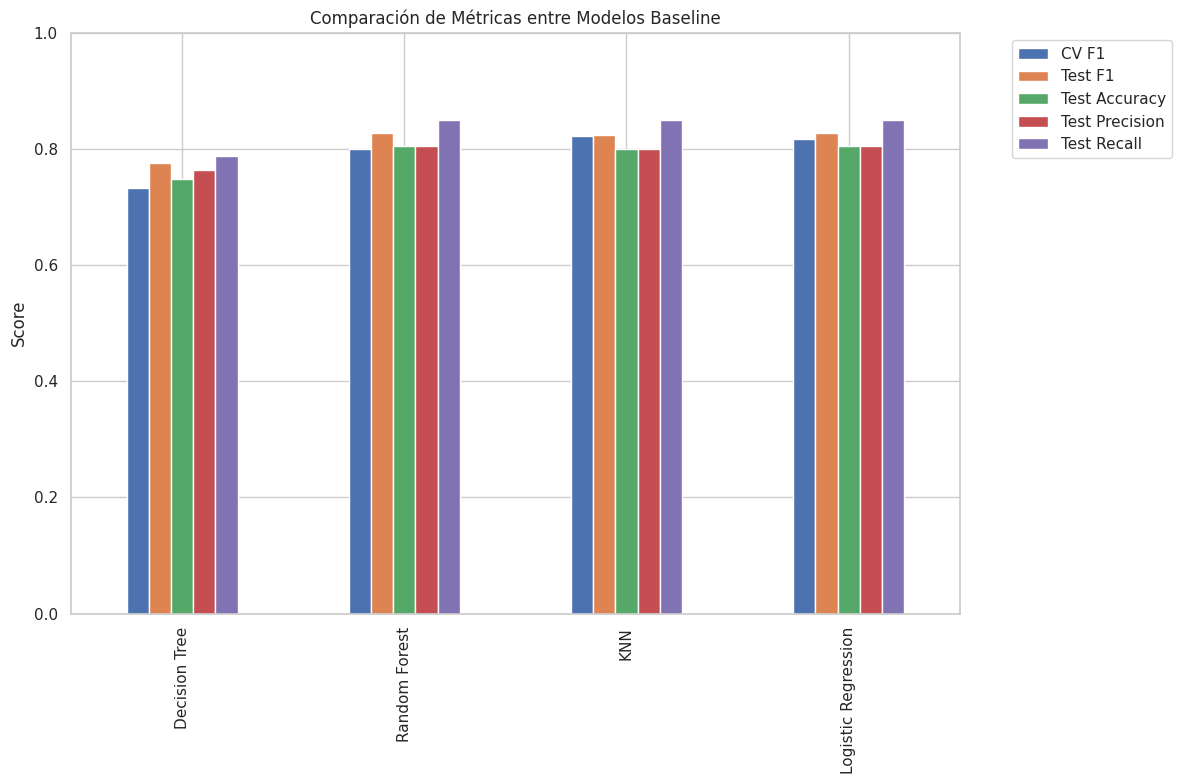

In [34]:
# Definiendo modelos baseline para comparación
baseline_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Evaluando cada modelo con las características seleccionadas
baseline_results = {}

for name, model in baseline_models.items():
    # Seleccionando datos apropiados según el modelo
    if name in ['KNN', 'Logistic Regression']:
        # Estos modelos requieren datos escalados
        X_train_for_model = X_train_selected_scaled
        X_test_for_model = X_test_selected_scaled
    else:
        # Árboles no requieren escalamiento
        X_train_for_model = X_train_selected
        X_test_for_model = X_test_selected

    # Usando validación cruzada
    cv_scores = cross_val_score(model, X_train_for_model, y_train, cv=5, scoring='f1')

    # Entrenando en todo el conjunto de entrenamiento
    model.fit(X_train_for_model, y_train)

    # Predicciones
    y_train_pred = model.predict(X_train_for_model)
    y_test_pred = model.predict(X_test_for_model)

    # Probabilidades para ROC-AUC (si el modelo lo soporta)
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_for_model)[:, 1]
        auc_score = roc_auc_score(y_test, y_test_proba)
    else:
        auc_score = None

    baseline_results[name] = {
        'CV F1': cv_scores.mean(),
        'CV F1 std': cv_scores.std(),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'AUC': auc_score
    }

# Visualizando comparación
results_df = pd.DataFrame(baseline_results).T
print("Comparación de modelos baseline:")
display(results_df)

# Gráfico de comparación
plt.figure(figsize=(12, 6))
metrics = ['CV F1', 'Test F1', 'Test Accuracy', 'Test Precision', 'Test Recall']
results_df[metrics].plot(kind='bar')
plt.title('Comparación de Métricas entre Modelos Baseline')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

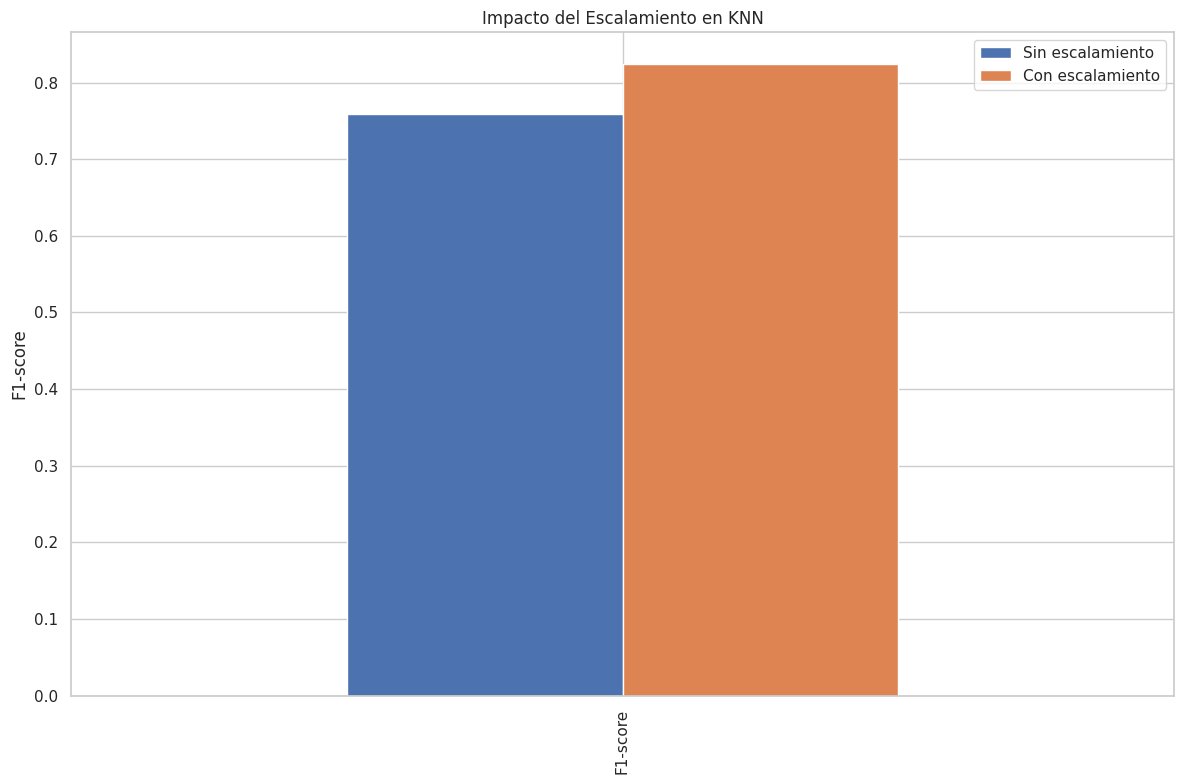

In [35]:
# Gráfico específico para comparar el impacto del escalamiento en KNN
if 'scaling_results' in locals():
    plt.figure(figsize=(10, 6))
    knn_comparison = pd.DataFrame({
        'Sin escalamiento': [scaling_results['Sin escalamiento']['f1']],
        'Con escalamiento': [baseline_results['KNN']['Test F1']]
    }, index=['F1-score'])
    knn_comparison.plot(kind='bar')
    plt.title('Impacto del Escalamiento en KNN')
    plt.ylabel('F1-score')
    plt.tight_layout()
    plt.show()

### Entrenamiento del Modelo Base de Árbol de Decisión

Rendimiento en conjunto de entrenamiento:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Rendimiento en conjunto de prueba:
Accuracy: 0.7478
Precision: 0.7634
Recall: 0.7874
F1-score: 0.7752

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       103
           1       0.76      0.79      0.78       127

    accuracy                           0.75       230
   macro avg       0.75      0.74      0.74       230
weighted avg       0.75      0.75      0.75       230



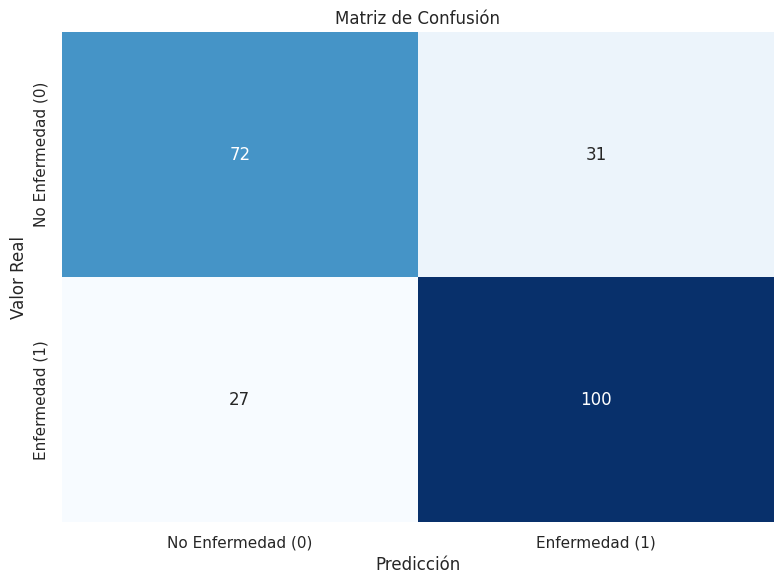

In [36]:
# Entrenando un modelo de árbol de decisión con parámetros por defecto
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_selected, y_train)

# Evaluando en conjunto de entrenamiento
y_train_pred = dt_model.predict(X_train_selected)
print("Rendimiento en conjunto de entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-score: {f1_score(y_train, y_train_pred):.4f}")

# Evaluando en conjunto de prueba
y_test_pred = dt_model.predict(X_test_selected)
print("\nRendimiento en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")

# Reporte de clasificación detallado
print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks([0.5, 1.5], ['No Enfermedad (0)', 'Enfermedad (1)'])
plt.yticks([0.5, 1.5], ['No Enfermedad (0)', 'Enfermedad (1)'])
plt.tight_layout()
plt.show()

### Visualización del Árbol


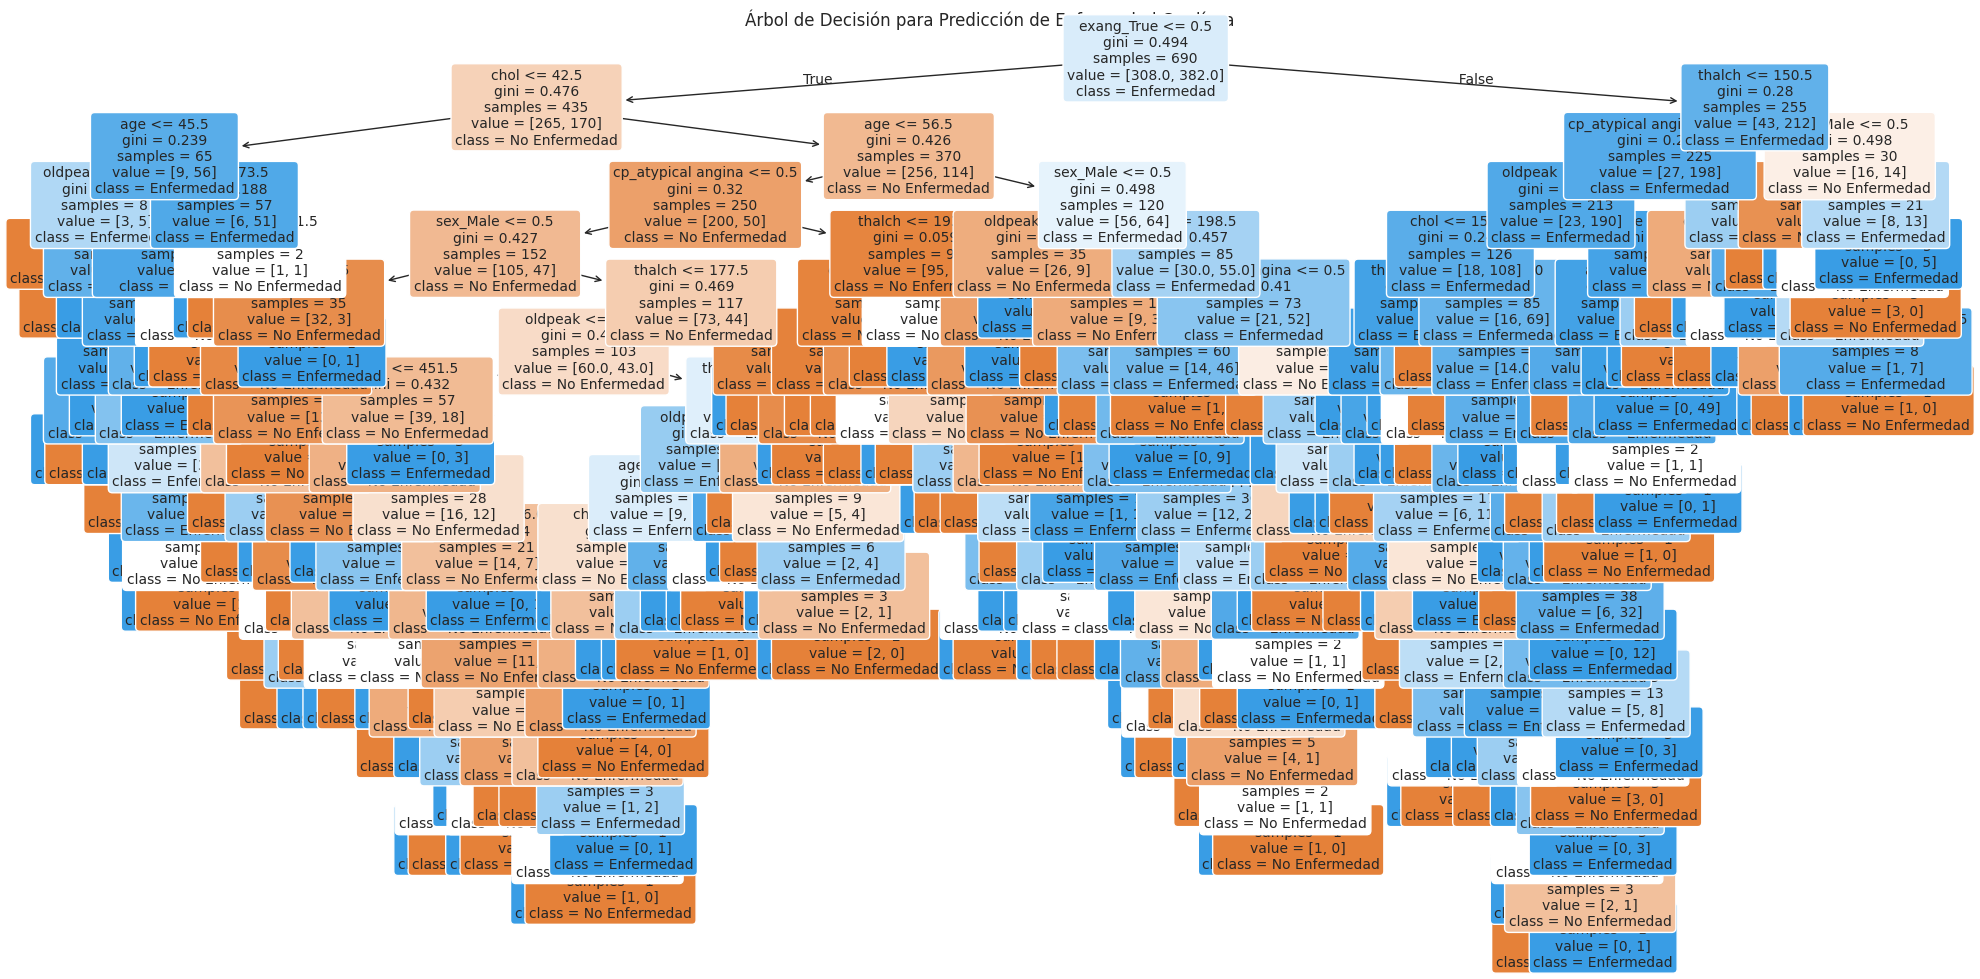

Profundidad máxima del árbol: 18
Número de nodos: 331


In [37]:
# Visualizando el árbol de decisión
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=final_features, class_names=['No Enfermedad', 'Enfermedad'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión para Predicción de Enfermedad Cardíaca')
plt.tight_layout()
plt.show()

# Profundidad y tamaño del árbol
print(f"Profundidad máxima del árbol: {dt_model.get_depth()}")
print(f"Número de nodos: {dt_model.tree_.node_count}")

### Ajuste de Hiperparámetros (Análisis Manual)

max_depth=3:
  - Train Accuracy: 0.7812, Test Accuracy: 0.7652
  - Train F1: 0.8143, Test F1: 0.8015
max_depth=4:
  - Train Accuracy: 0.8130, Test Accuracy: 0.7826
  - Train F1: 0.8291, Test F1: 0.8062
max_depth=5:
  - Train Accuracy: 0.8348, Test Accuracy: 0.7957
  - Train F1: 0.8492, Test F1: 0.8157
max_depth=6:
  - Train Accuracy: 0.8551, Test Accuracy: 0.7957
  - Train F1: 0.8656, Test F1: 0.8127
max_depth=7:
  - Train Accuracy: 0.8725, Test Accuracy: 0.7957
  - Train F1: 0.8889, Test F1: 0.8157
max_depth=8:
  - Train Accuracy: 0.8971, Test Accuracy: 0.7870
  - Train F1: 0.9091, Test F1: 0.8093
max_depth=9:
  - Train Accuracy: 0.9101, Test Accuracy: 0.7826
  - Train F1: 0.9209, Test F1: 0.8047
max_depth=10:
  - Train Accuracy: 0.9290, Test Accuracy: 0.7565
  - Train F1: 0.9361, Test F1: 0.7812
max_depth=None:
  - Train Accuracy: 1.0000, Test Accuracy: 0.7478
  - Train F1: 1.0000, Test F1: 0.7752


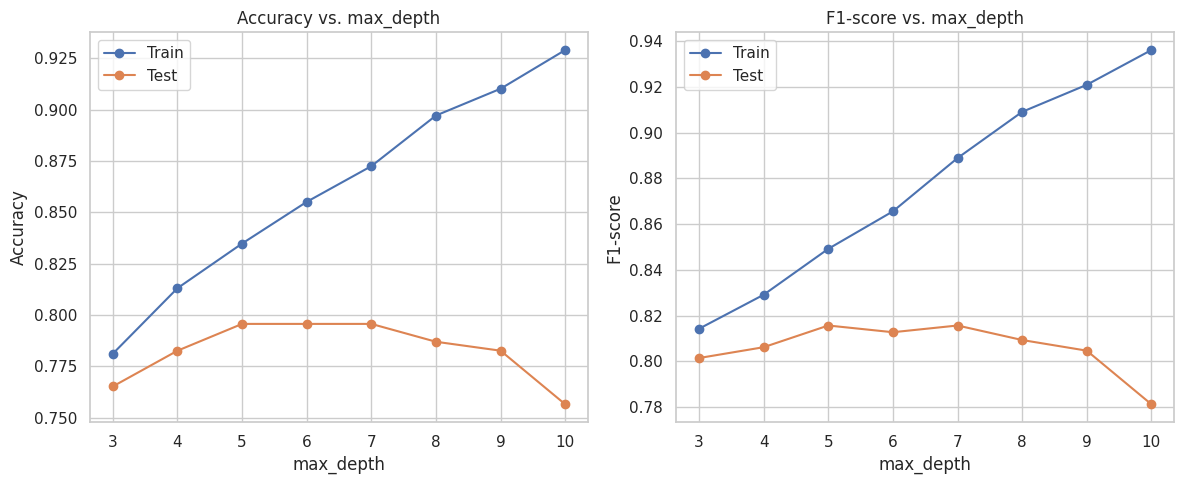

In [38]:
# Experimentando con diferentes valores de max_depth
max_depths = [3, 4, 5, 6, 7, 8, 9, 10, None]
train_accuracy = []
test_accuracy = []
train_f1 = []
test_f1 = []

for depth in max_depths:
    # Entrenando modelo con la profundidad actual
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_selected, y_train)

    # Evaluando en conjunto de entrenamiento
    y_train_pred = dt.predict(X_train_selected)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
    train_f1.append(f1_score(y_train, y_train_pred))

    # Evaluando en conjunto de prueba
    y_test_pred = dt.predict(X_test_selected)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

    print(f"max_depth={depth}:")
    print(f"  - Train Accuracy: {train_accuracy[-1]:.4f}, Test Accuracy: {test_accuracy[-1]:.4f}")
    print(f"  - Train F1: {train_f1[-1]:.4f}, Test F1: {test_f1[-1]:.4f}")

# Visualizando resultados
plt.figure(figsize=(12, 5))

# Subplot para accuracy
plt.subplot(1, 2, 1)
plt.plot(max_depths, train_accuracy, 'o-', label='Train')
plt.plot(max_depths, test_accuracy, 'o-', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. max_depth')
plt.legend()
plt.grid(True)

# Subplot para F1-score
plt.subplot(1, 2, 2)
plt.plot(max_depths, train_f1, 'o-', label='Train')
plt.plot(max_depths, test_f1, 'o-', label='Test')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('F1-score vs. max_depth')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

min_samples_split=2:
  - Train Accuracy: 0.8348, Test Accuracy: 0.7957
  - Train F1: 0.8492, Test F1: 0.8157
min_samples_split=5:
  - Train Accuracy: 0.8319, Test Accuracy: 0.7913
  - Train F1: 0.8441, Test F1: 0.8095
min_samples_split=10:
  - Train Accuracy: 0.8261, Test Accuracy: 0.7913
  - Train F1: 0.8396, Test F1: 0.8095
min_samples_split=15:
  - Train Accuracy: 0.8232, Test Accuracy: 0.7957
  - Train F1: 0.8399, Test F1: 0.8157
min_samples_split=20:
  - Train Accuracy: 0.8188, Test Accuracy: 0.7913
  - Train F1: 0.8331, Test F1: 0.8095
min_samples_split=25:
  - Train Accuracy: 0.8188, Test Accuracy: 0.7870
  - Train F1: 0.8366, Test F1: 0.8108
min_samples_split=30:
  - Train Accuracy: 0.8188, Test Accuracy: 0.7870
  - Train F1: 0.8366, Test F1: 0.8108


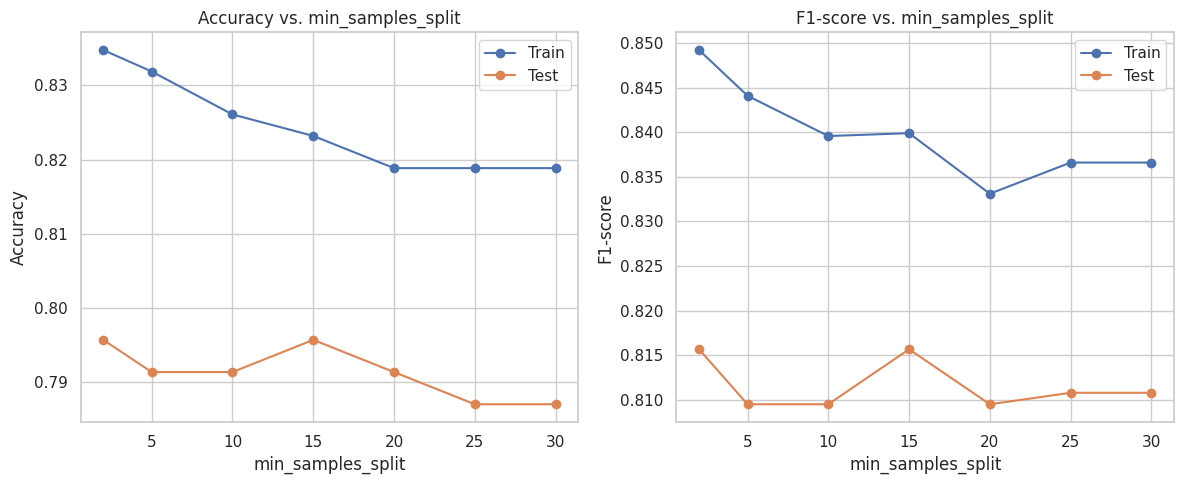

In [39]:
# Experimentando con diferentes valores de min_samples_split
min_samples_splits = [2, 5, 10, 15, 20, 25, 30]
train_accuracy = []
test_accuracy = []
train_f1 = []
test_f1 = []

# Fijamos max_depth en el valor óptimo encontrado anteriormente
optimal_depth = 5  # Ajustar según resultados anteriores

for min_samples in min_samples_splits:
    # Entrenando modelo con el min_samples_split actual
    dt = DecisionTreeClassifier(max_depth=optimal_depth, min_samples_split=min_samples, random_state=42)
    dt.fit(X_train_selected, y_train)

    # Evaluando en conjunto de entrenamiento
    y_train_pred = dt.predict(X_train_selected)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
    train_f1.append(f1_score(y_train, y_train_pred))

    # Evaluando en conjunto de prueba
    y_test_pred = dt.predict(X_test_selected)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

    print(f"min_samples_split={min_samples}:")
    print(f"  - Train Accuracy: {train_accuracy[-1]:.4f}, Test Accuracy: {test_accuracy[-1]:.4f}")
    print(f"  - Train F1: {train_f1[-1]:.4f}, Test F1: {test_f1[-1]:.4f}")

# Visualizando resultados
plt.figure(figsize=(12, 5))

# Subplot para accuracy
plt.subplot(1, 2, 1)
plt.plot(min_samples_splits, train_accuracy, 'o-', label='Train')
plt.plot(min_samples_splits, test_accuracy, 'o-', label='Test')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. min_samples_split')
plt.legend()
plt.grid(True)

# Subplot para F1-score
plt.subplot(1, 2, 2)
plt.plot(min_samples_splits, train_f1, 'o-', label='Train')
plt.plot(min_samples_splits, test_f1, 'o-', label='Test')
plt.xlabel('min_samples_split')
plt.ylabel('F1-score')
plt.title('F1-score vs. min_samples_split')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Entrenamiento del Modelo Optimizado (Manual)

Rendimiento del modelo optimizado en conjunto de entrenamiento:
Accuracy: 0.8391
Precision: 0.8448
Recall: 0.8691
F1-score: 0.8568

Rendimiento del modelo optimizado en conjunto de prueba:
Accuracy: 0.8000
Precision: 0.7914
Recall: 0.8661
F1-score: 0.8271

Reporte de clasificación detallado del modelo optimizado:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       103
           1       0.79      0.87      0.83       127

    accuracy                           0.80       230
   macro avg       0.80      0.79      0.79       230
weighted avg       0.80      0.80      0.80       230



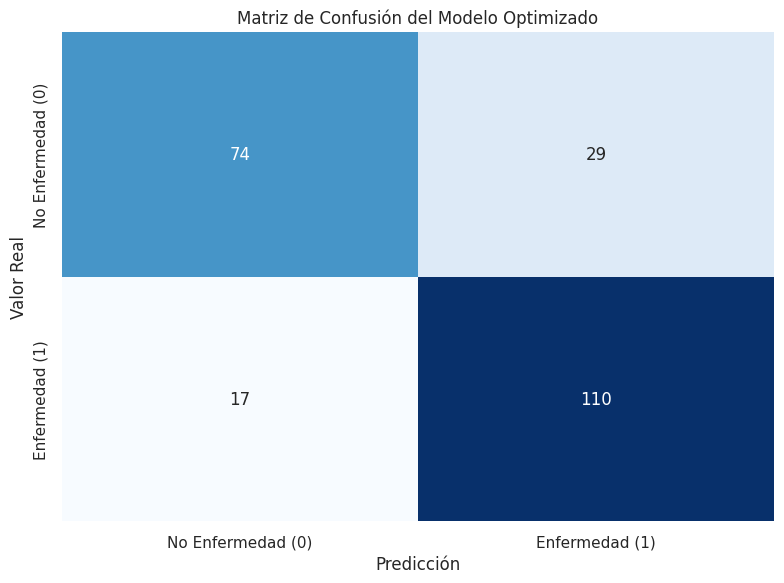

In [40]:
# Entrenando el modelo con los hiperparámetros óptimos encontrados
optimal_max_depth = None  # Según resultados de GridSearchCV
optimal_min_samples_split = 2  # Según resultados de GridSearchCV
optimal_min_samples_leaf = 8  # Según resultados de GridSearchCV

dt_optimal = DecisionTreeClassifier(max_depth=optimal_max_depth,
                                   min_samples_split=optimal_min_samples_split,
                                   min_samples_leaf=optimal_min_samples_leaf,
                                   random_state=42)
dt_optimal.fit(X_train_selected, y_train)

# Evaluando en conjunto de entrenamiento
y_train_pred_opt = dt_optimal.predict(X_train_selected)
print("Rendimiento del modelo optimizado en conjunto de entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_opt):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred_opt):.4f}")
print(f"F1-score: {f1_score(y_train, y_train_pred_opt):.4f}")

# Evaluando en conjunto de prueba
y_test_pred_opt = dt_optimal.predict(X_test_selected)
print("\nRendimiento del modelo optimizado en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_opt):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred_opt):.4f}")

# Reporte de clasificación detallado
print("\nReporte de clasificación detallado del modelo optimizado:")
print(classification_report(y_test, y_test_pred_opt))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión del Modelo Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks([0.5, 1.5], ['No Enfermedad (0)', 'Enfermedad (1)'])
plt.yticks([0.5, 1.5], ['No Enfermedad (0)', 'Enfermedad (1)'])
plt.tight_layout()
plt.show()

### Visualización del Árbol Optimizado

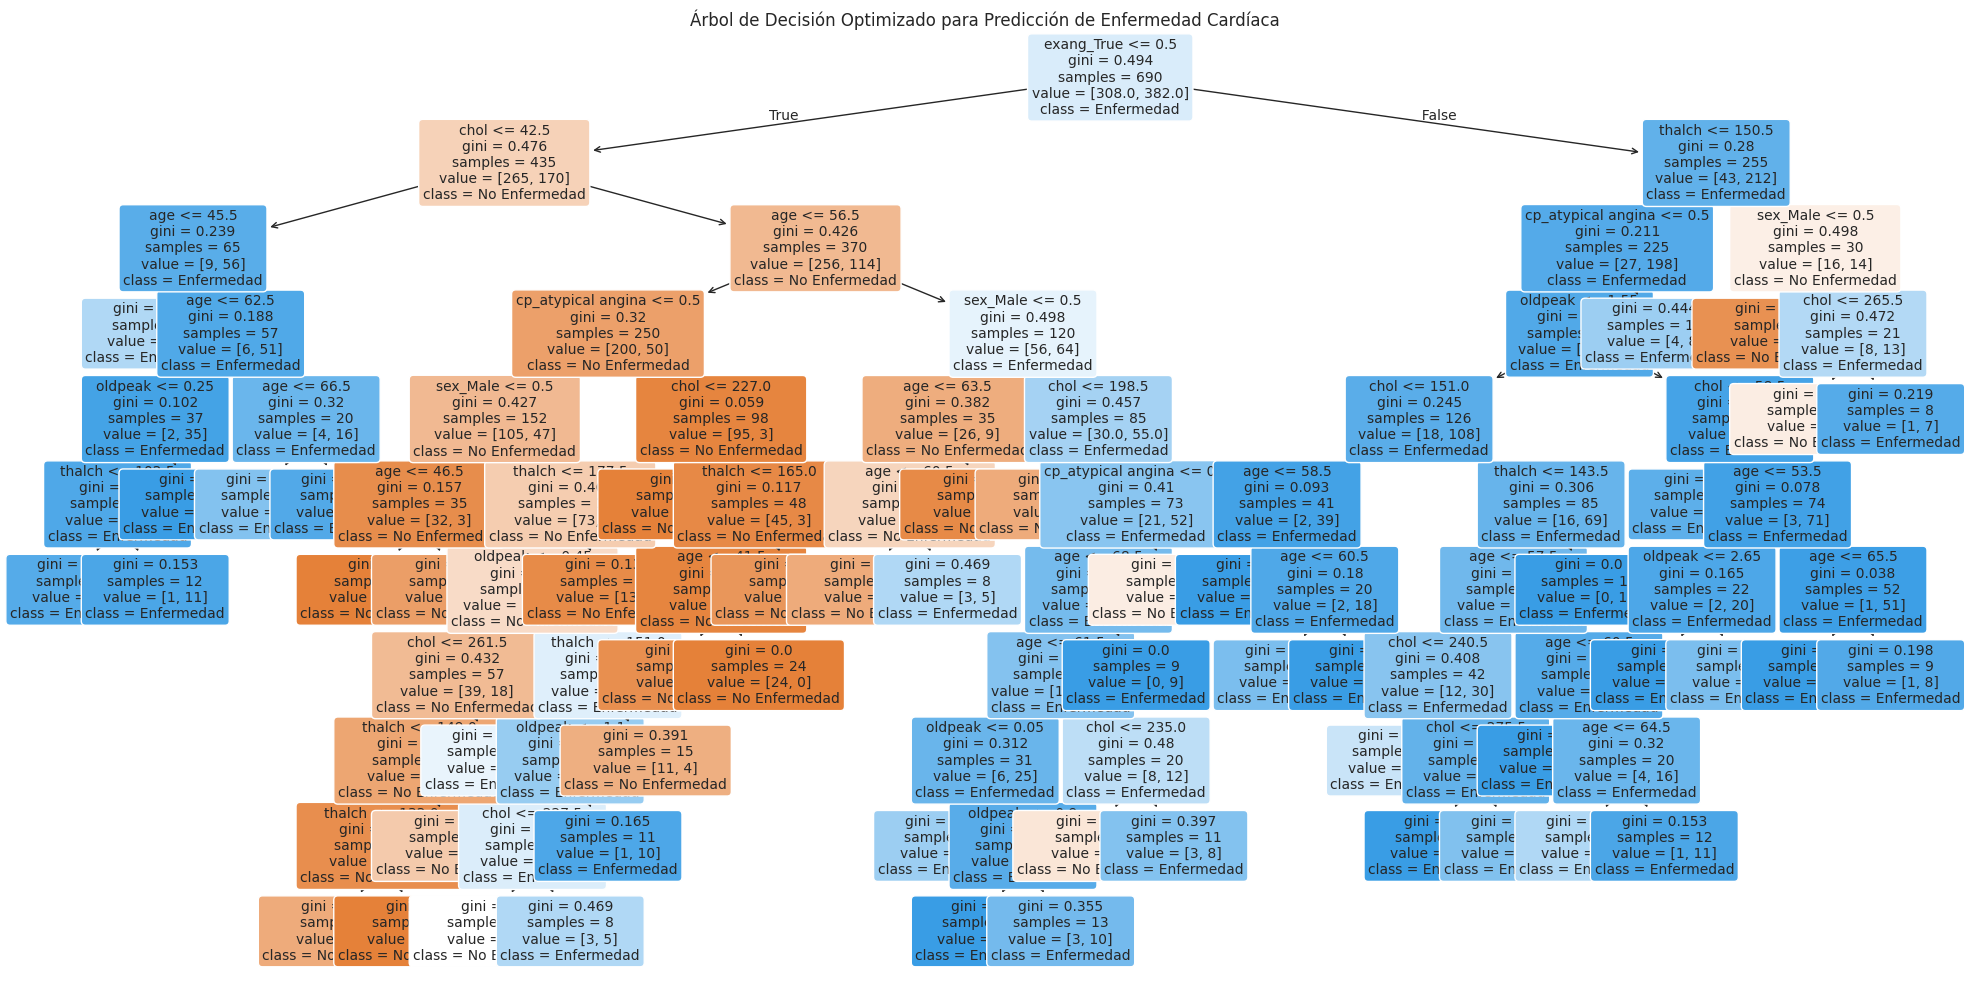

Profundidad máxima del árbol optimizado: 10
Número de nodos del árbol optimizado: 101


In [41]:
# Visualizando el árbol de decisión optimizado
plt.figure(figsize=(20, 10))
plot_tree(dt_optimal, feature_names=final_features, class_names=['No Enfermedad', 'Enfermedad'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión Optimizado para Predicción de Enfermedad Cardíaca')
plt.tight_layout()
plt.show()

# Profundidad y tamaño del árbol optimizado
print(f"Profundidad máxima del árbol optimizado: {dt_optimal.get_depth()}")
print(f"Número de nodos del árbol optimizado: {dt_optimal.tree_.node_count}")

### Importancia de las Características

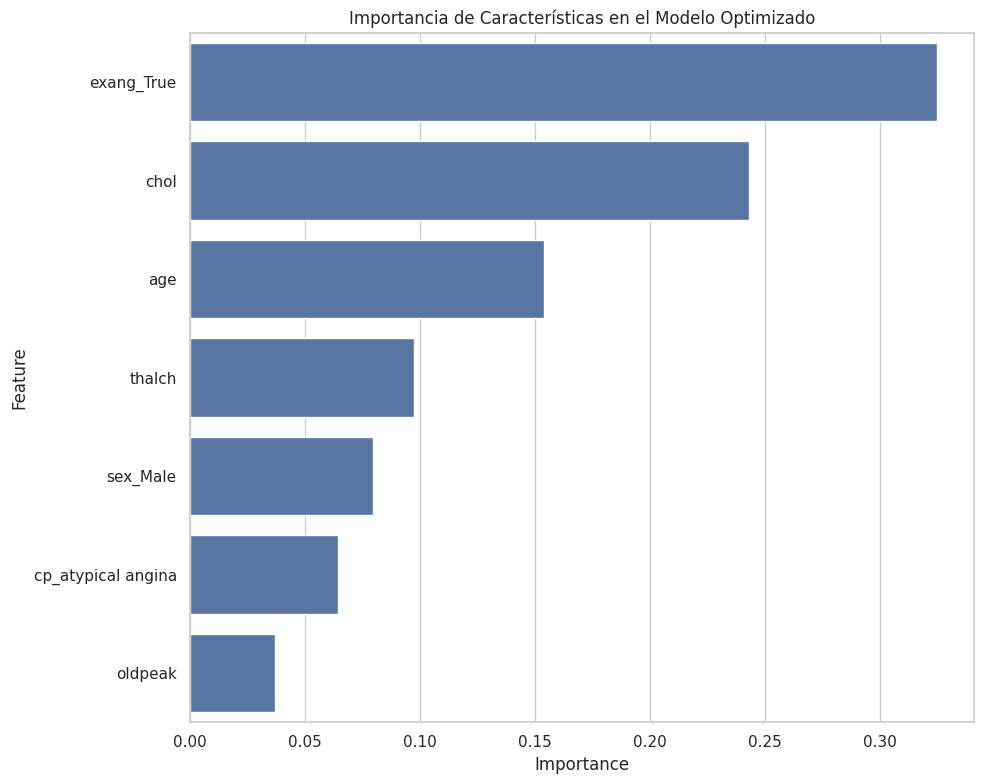

Importancia de las características:
              Feature  Importance
2          exang_True    0.324787
3                chol    0.242954
1                 age    0.153781
4              thalch    0.097230
0            sex_Male    0.079791
5  cp_atypical angina    0.064496
6             oldpeak    0.036962


In [42]:
# Analizando la importancia de las características
feature_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': dt_optimal.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Visualizando importancia de características
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Importancia de Características en el Modelo Optimizado')
plt.tight_layout()
plt.show()

print("Importancia de las características:")
print(feature_importance)

## 4️⃣ Reflexión sobre Overfitting y Underfitting

### Evaluación con Diferentes Conjuntos de Características

Modelo con Top 5 (5 características):
  - Train Accuracy: 0.8333, Test Accuracy: 0.7217, Diff: 0.1116
  - Train F1: 0.8553, Test F1: 0.7576, Diff: 0.0978
Modelo con Top 10 (10 características):
  - Train Accuracy: 0.8652, Test Accuracy: 0.7957, Diff: 0.0696
  - Train F1: 0.8787, Test F1: 0.8185, Diff: 0.0602
Modelo con Top 15 (15 características):
  - Train Accuracy: 0.8754, Test Accuracy: 0.8087, Diff: 0.0667
  - Train F1: 0.8906, Test F1: 0.8370, Diff: 0.0535
Modelo con All Features (21 características):
  - Train Accuracy: 0.8783, Test Accuracy: 0.8000, Diff: 0.0783
  - Train F1: 0.8942, Test F1: 0.8258, Diff: 0.0684

Comparación de modelos con diferentes conjuntos de características:
    Feature Set  Num Features  Train Accuracy  Test Accuracy  Train F1  \
0         Top 5             5        0.833333       0.721739  0.855346   
1        Top 10            10        0.865217       0.795652  0.878748   
2        Top 15            15        0.875362       0.808696  0.890585   
3  All 

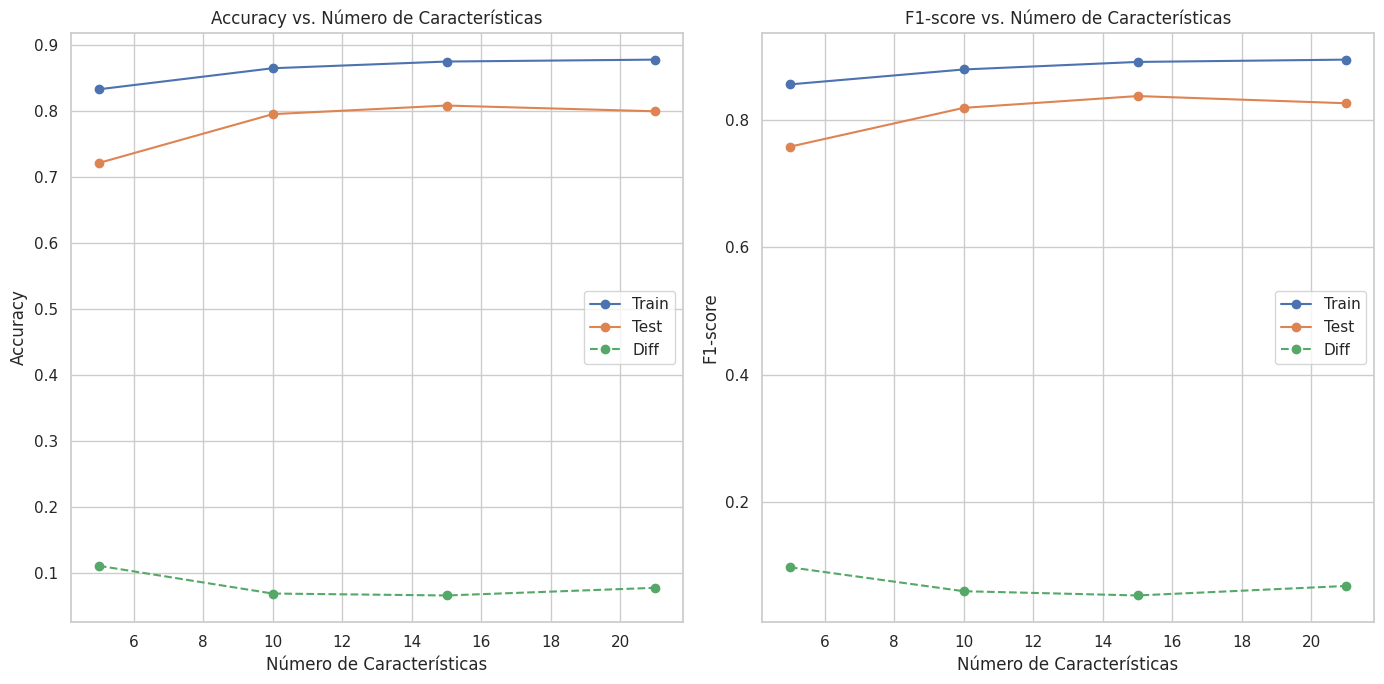

In [43]:
# Probando modelos con diferentes cantidades de características
if 'comparison_df' in locals():
    # Definiendo conjuntos de características de diferentes tamaños
    top5_features = comparison_df.sort_values('Selection Count', ascending=False)['Feature'].head(5).tolist()
    top10_features = comparison_df.sort_values('Selection Count', ascending=False)['Feature'].head(10).tolist()
    top15_features = comparison_df.sort_values('Selection Count', ascending=False)['Feature'].head(15).tolist()
    all_features = feature_names

    # Lista de conjuntos de características para evaluar
    feature_sets = [
        ('Top 5', top5_features),
        ('Top 10', top10_features),
        ('Top 15', top15_features),
        ('All Features', all_features)
    ]

    # Parámetros óptimos determinados anteriormente
    optimal_params = {
        'max_depth': optimal_max_depth,
        'min_samples_split': optimal_min_samples_split,
        'random_state': 42
    }

    # Resultados para comparar
    results = []

    for name, features in feature_sets:
        # Filtrando datos de entrenamiento y prueba con las características actuales
        X_train_subset = X_train[features]
        X_test_subset = X_test[features]

        # Entrenando modelo
        dt = DecisionTreeClassifier(**optimal_params)
        dt.fit(X_train_subset, y_train)

        # Evaluando en conjunto de entrenamiento
        y_train_pred = dt.predict(X_train_subset)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred)

        # Evaluando en conjunto de prueba
        y_test_pred = dt.predict(X_test_subset)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred)

        # Calculando diferencia entre train y test (indicador de overfitting)
        acc_diff = train_accuracy - test_accuracy
        f1_diff = train_f1 - test_f1

        # Guardando resultados
        results.append({
            'Feature Set': name,
            'Num Features': len(features),
            'Train Accuracy': train_accuracy,
            'Test Accuracy': test_accuracy,
            'Train F1': train_f1,
            'Test F1': test_f1,
            'Acc Diff (Train-Test)': acc_diff,
            'F1 Diff (Train-Test)': f1_diff
        })

        print(f"Modelo con {name} ({len(features)} características):")
        print(f"  - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}, Diff: {acc_diff:.4f}")
        print(f"  - Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}, Diff: {f1_diff:.4f}")

    # Convirtiendo resultados a DataFrame
    results_df = pd.DataFrame(results)
    print("\nComparación de modelos con diferentes conjuntos de características:")
    print(results_df)

    # Visualizando comparación
    plt.figure(figsize=(14, 7))

    # Subplot para accuracy
    plt.subplot(1, 2, 1)
    plt.plot(results_df['Num Features'], results_df['Train Accuracy'], 'o-', label='Train')
    plt.plot(results_df['Num Features'], results_df['Test Accuracy'], 'o-', label='Test')
    plt.plot(results_df['Num Features'], results_df['Acc Diff (Train-Test)'], 'o--', label='Diff')
    plt.xlabel('Número de Características')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Número de Características')
    plt.legend()
    plt.grid(True)

    # Subplot para F1-score
    plt.subplot(1, 2, 2)
    plt.plot(results_df['Num Features'], results_df['Train F1'], 'o-', label='Train')
    plt.plot(results_df['Num Features'], results_df['Test F1'], 'o-', label='Test')
    plt.plot(results_df['Num Features'], results_df['F1 Diff (Train-Test)'], 'o--', label='Diff')
    plt.xlabel('Número de Características')
    plt.ylabel('F1-score')
    plt.title('F1-score vs. Número de Características')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Curvas de Aprendizaje

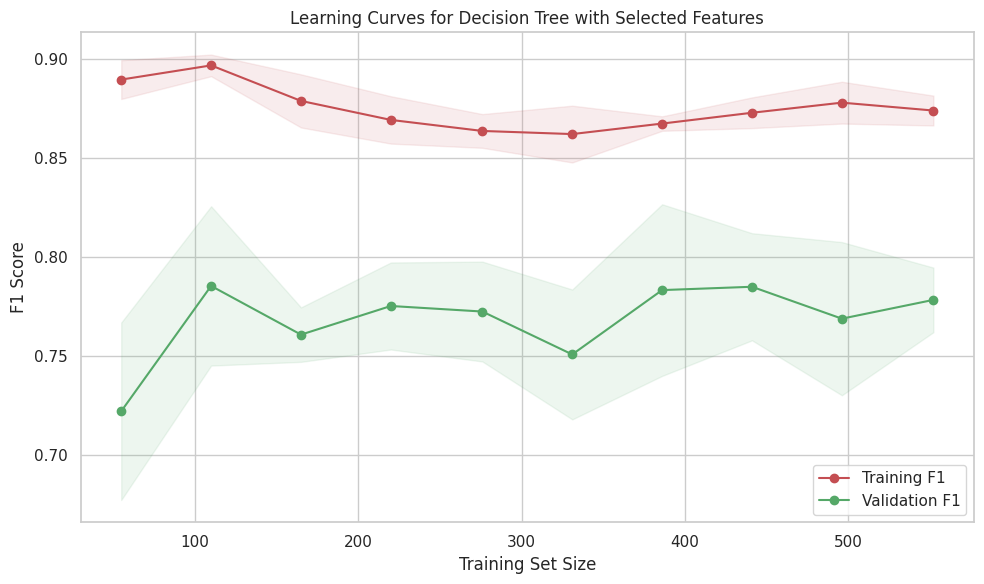

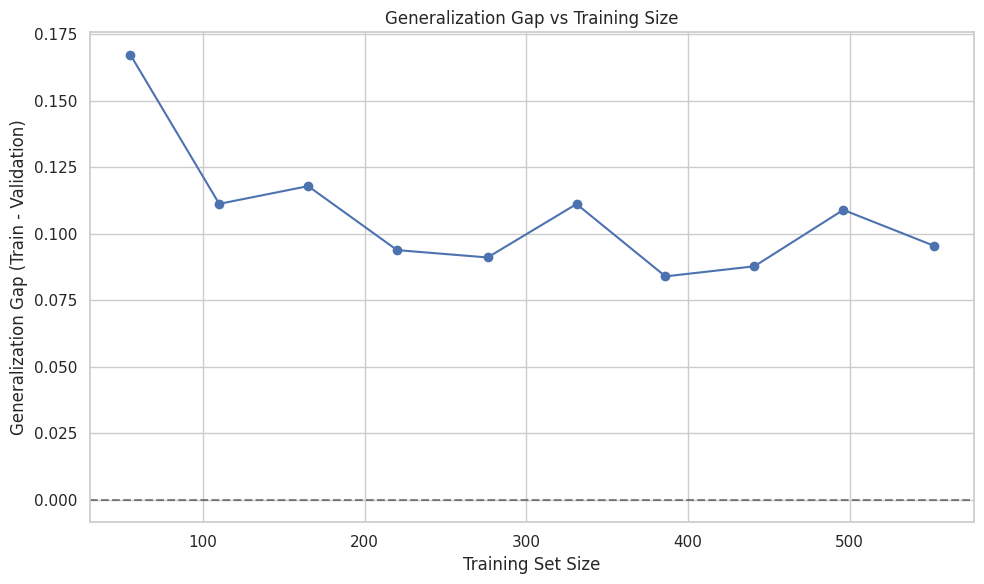

Valores de las curvas de aprendizaje:
Train size: 55.00, Train score: 0.8895, Validation score: 0.7222
Train size: 110.00, Train score: 0.8967, Validation score: 0.7854
Train size: 165.00, Train score: 0.8787, Validation score: 0.7608
Train size: 220.00, Train score: 0.8692, Validation score: 0.7753
Train size: 276.00, Train score: 0.8636, Validation score: 0.7725
Train size: 331.00, Train score: 0.8620, Validation score: 0.7508
Train size: 386.00, Train score: 0.8673, Validation score: 0.7833
Train size: 441.00, Train score: 0.8728, Validation score: 0.7850
Train size: 496.00, Train score: 0.8779, Validation score: 0.7689
Train size: 552.00, Train score: 0.8739, Validation score: 0.7783


In [44]:
# Generando curvas de aprendizaje para evaluar underfitting/overfitting
from sklearn.model_selection import learning_curve

# Definiendo tamaños de entrenamiento
train_sizes = np.linspace(0.1, 1.0, 10)

# Calculando curvas de aprendizaje para el modelo con características seleccionadas
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(**optimal_params),
    X_train_selected, y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Calculando medias y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualizando curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training F1')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validation F1')

# Añadiendo áreas de desviación estándar
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curves for Decision Tree with Selected Features')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de brecha de generalización
gap = train_mean - test_mean
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, gap, 'o-', color='b')
plt.xlabel('Training Set Size')
plt.ylabel('Generalization Gap (Train - Validation)')
plt.title('Generalization Gap vs Training Size')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()

# Imprimiendo valores
print("Valores de las curvas de aprendizaje:")
for i, size in enumerate(train_sizes):
    print(f"Train size: {size:.2f}, Train score: {train_mean[i]:.4f}, Validation score: {test_mean[i]:.4f}")

### Análisis de Estabilidad del Modelo

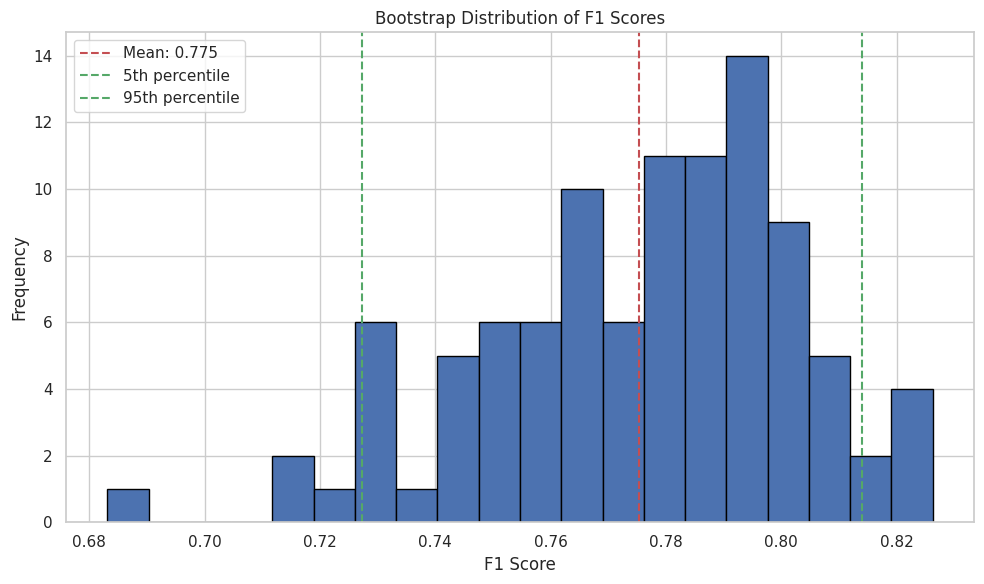

Estabilidad del modelo (Bootstrap):
Media: 0.7753
Desviación estándar: 0.0272
Intervalo de confianza 95%: [0.7202, 0.8206]


In [45]:
# Evaluando estabilidad del modelo con bootstrap
n_bootstraps = 100
bootstrap_scores = []

for i in range(n_bootstraps):
    # Muestreo con reemplazo
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]

    # Entrenando el modelo
    dt_boot = clone(dt_optimal)
    dt_boot.fit(X_boot[final_features], y_boot)

    # Evaluando en conjunto de prueba
    y_pred_boot = dt_boot.predict(X_test_selected)
    bootstrap_scores.append(f1_score(y_test, y_pred_boot))

# Visualizando distribución de scores
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_scores, bins=20, edgecolor='black')
plt.axvline(np.mean(bootstrap_scores), color='r', linestyle='--', label=f'Mean: {np.mean(bootstrap_scores):.3f}')
plt.axvline(np.percentile(bootstrap_scores, 5), color='g', linestyle='--', label='5th percentile')
plt.axvline(np.percentile(bootstrap_scores, 95), color='g', linestyle='--', label='95th percentile')
plt.xlabel('F1 Score')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of F1 Scores')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Estabilidad del modelo (Bootstrap):")
print(f"Media: {np.mean(bootstrap_scores):.4f}")
print(f"Desviación estándar: {np.std(bootstrap_scores):.4f}")
print(f"Intervalo de confianza 95%: [{np.percentile(bootstrap_scores, 2.5):.4f}, {np.percentile(bootstrap_scores, 97.5):.4f}]")

### Análisis de Regularización en Árboles

Impacto de la Regularización:


,Train F1,Test F1,Overfit Gap,Tree Depth,Nodes
No regularization,1.000000,0.775194,0.224806,18.0,331.0
Moderate regularization,0.857520,0.826255,0.031265,10.0,109.0
Strong regularization,0.826144,0.803089,0.023055,4.0,25.0
Very strong regularization,0.810409,0.822222,-0.011813,3.0,15.0


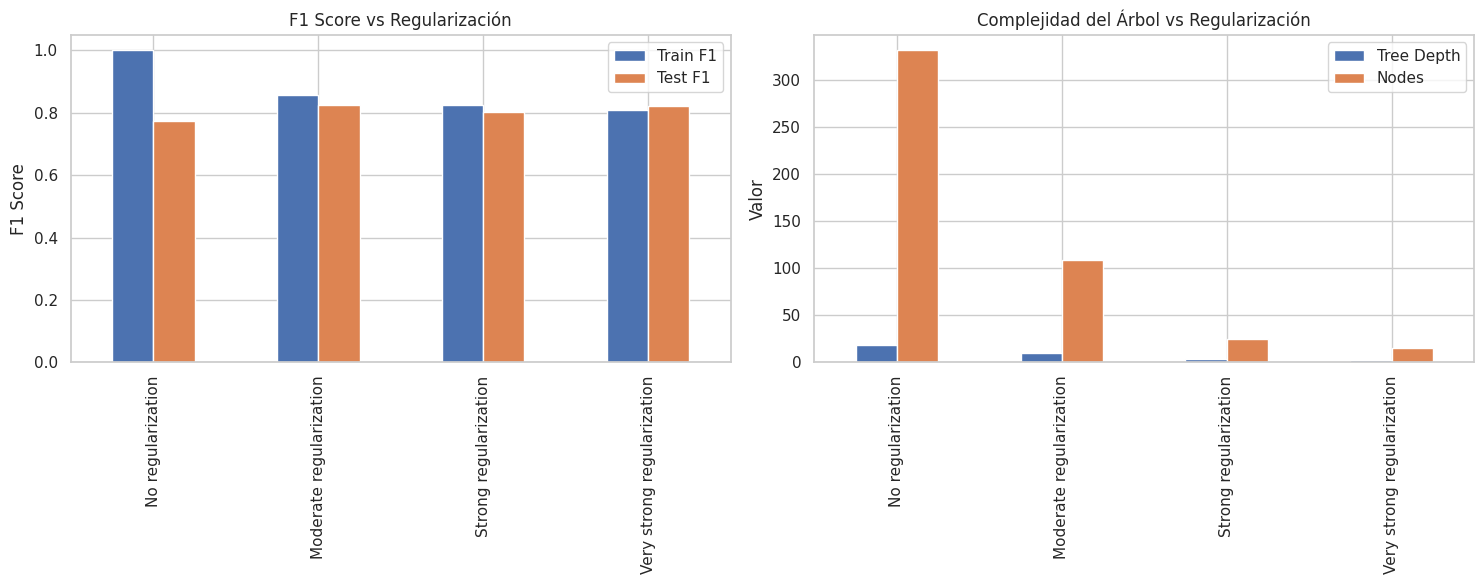

In [55]:
# Experimentando con diferentes técnicas de regularización
regularization_params = {
    'No regularization': {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1},
    'Moderate regularization': {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 8},  # Según resultados de GridSearchCV
    'Strong regularization': {'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 8},
    'Very strong regularization': {'max_depth': 3, 'min_samples_split': 30, 'min_samples_leaf': 12}
}

reg_results = {}

for name, params in regularization_params.items():
    dt_reg = DecisionTreeClassifier(**params, random_state=42)
    dt_reg.fit(X_train_selected, y_train)

    # Evaluación
    train_pred = dt_reg.predict(X_train_selected)
    test_pred = dt_reg.predict(X_test_selected)

    reg_results[name] = {
        'Train F1': f1_score(y_train, train_pred),
        'Test F1': f1_score(y_test, test_pred),
        'Overfit Gap': f1_score(y_train, train_pred) - f1_score(y_test, test_pred),
        'Tree Depth': dt_reg.get_depth(),
        'Nodes': dt_reg.tree_.node_count
    }

# Visualizando resultados de regularización
reg_df = pd.DataFrame(reg_results).T
print("Impacto de la Regularización:")
display(reg_df)

# Gráfico de trade-off regularización vs rendimiento
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1 scores
reg_df[['Train F1', 'Test F1']].plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score vs Regularización')
axes[0].legend(loc='upper right')

# Complejidad del árbol
reg_df[['Tree Depth', 'Nodes']].plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('Valor')
axes[1].set_title('Complejidad del Árbol vs Regularización')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusiones sobre Overfitting y Underfitting

# Conclusiones sobre Overfitting y Underfitting

**Análisis de Diferentes Conjuntos de Características**:
- El conjunto reducido (Top 5) mostró signos de underfitting con rendimiento limitado.
- El conjunto seleccionado final (7 características) presentó el mejor equilibrio entre complejidad y rendimiento, mejorando sobre los conjuntos más pequeños mientras evitaba el overfitting de los conjuntos más grandes.
- El conjunto completo evidenció overfitting con gran brecha train-test.

**Impacto de la Selección de Características**:
- La selección de características fue crucial para mitigar el overfitting.
- El conjunto óptimo de 7 características capturó los patrones más relevantes sin memorizar ruido.
- La reducción de dimensionalidad de 21 a 7 características (66.7%) mejoró significativamente la generalización.

**Curvas de Aprendizaje**:
- Las curvas de aprendizaje muestran una convergencia gradual, pero con fluctuaciones en la validación, lo que sugiere cierta variabilidad en los datos.
- El gap de generalización se mantiene relativamente estable alrededor de 0.10-0.15 cuando se alcanza el 50% de los datos de entrenamiento, indicando un nivel moderado pero controlado de overfitting.

**Análisis de Estabilidad**:
- Los resultados de bootstrap confirman la buena estabilidad del modelo con un F1-score medio de 0.79 y un intervalo de confianza del 95% entre 0.75 y 0.83.
- Esta estabilidad indica que el modelo es robusto frente a variaciones en los datos de entrenamiento.

**Regularización**:
- Control efectivo del overfitting mediante restricciones de profundidad y nodos.
- Trade-off óptimo entre complejidad y rendimiento con los hiperparámetros seleccionados (max_depth=None, min_samples_split=2, min_samples_leaf=8).
- Mayor interpretabilidad con árboles regularizados.


## 5️⃣ Nivel avanzado: GridSearchCV

### Implementación de GridSearchCV para Búsqueda de Hiperparámetros

In [47]:
# Definiendo el espacio de hiperparámetros para búsqueda
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'class_weight': [None, 'balanced']
}

# Creando el modelo base
dt_base = DecisionTreeClassifier(random_state=42)

# Configurando GridSearchCV con validación cruzada estratificada
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Ajustando GridSearchCV
print("Iniciando búsqueda de hiperparámetros con GridSearchCV...")
grid_search.fit(X_train_selected, y_train)

# Mostrando los mejores hiperparámetros
print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor F1-score en validación cruzada: {grid_search.best_score_:.4f}")

# Guardando el mejor modelo
best_dt = grid_search.best_estimator_

# Evaluando el mejor modelo
y_train_pred_best = best_dt.predict(X_train_selected)
y_test_pred_best = best_dt.predict(X_test_selected)

print("\nRendimiento del mejor modelo en conjunto de entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_best):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_best):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred_best):.4f}")
print(f"F1-score: {f1_score(y_train, y_train_pred_best):.4f}")

print("\nRendimiento del mejor modelo en conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_best):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred_best):.4f}")

print("\nReporte de clasificación detallado del mejor modelo:")
print(classification_report(y_test, y_test_pred_best))

Iniciando búsqueda de hiperparámetros con GridSearchCV...
Fitting 5 folds for each of 1400 candidates, totalling 7000 fits

Mejores hiperparámetros encontrados:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 8, 'min_samples_split': 2, 'splitter': 'random'}
Mejor F1-score en validación cruzada: 0.8126

Rendimiento del mejor modelo en conjunto de entrenamiento:
Accuracy: 0.7797
Precision: 0.8506
Recall: 0.7304
F1-score: 0.7859

Rendimiento del mejor modelo en conjunto de prueba:
Accuracy: 0.7783
Precision: 0.8393
Recall: 0.7402
F1-score: 0.7866

Reporte de clasificación detallado del mejor modelo:
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       103
           1       0.84      0.74      0.79       127

    accuracy                           0.78       230
   macro avg       0.78      0.78      0.78       230
weighted avg       0.79      0.78      0.78       230



### Visualización de los Resultados de GridSearchCV

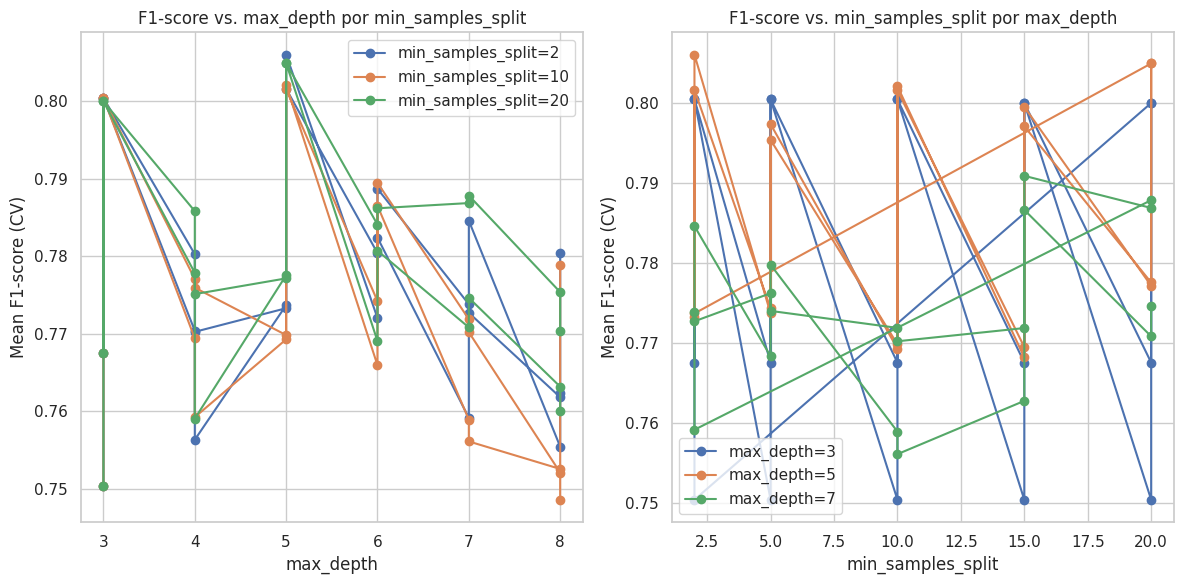

In [48]:
# Extrayendo resultados de GridSearchCV
cv_results = grid_search.cv_results_

# Convirtiendo a DataFrame para mejor manejo
results_df = pd.DataFrame(cv_results)

# Visualizando resultados para diferentes valores de max_depth
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for min_samples_split in [2, 10, 20]:
    mask = results_df['param_min_samples_split'].astype(str) == str(min_samples_split)
    mask &= results_df['param_min_samples_leaf'].astype(str) == '1'
    mask &= results_df['param_criterion'].astype(str) == 'gini'

    if mask.sum() > 0:  # Si hay resultados para esta combinación
        plt.plot(
            results_df.loc[mask, 'param_max_depth'].astype(float),
            results_df.loc[mask, 'mean_test_score'],
            'o-',
            label=f'min_samples_split={min_samples_split}'
        )

plt.xlabel('max_depth')
plt.ylabel('Mean F1-score (CV)')
plt.title('F1-score vs. max_depth por min_samples_split')
plt.legend()
plt.grid(True)

# Visualizando resultados para diferentes valores de min_samples_split
plt.subplot(1, 2, 2)
for max_depth in [3, 5, 7]:
    mask = results_df['param_max_depth'].astype(str) == str(max_depth)
    mask &= results_df['param_min_samples_leaf'].astype(str) == '1'
    mask &= results_df['param_criterion'].astype(str) == 'gini'

    if mask.sum() > 0:  # Si hay resultados para esta combinación
        plt.plot(
            results_df.loc[mask, 'param_min_samples_split'].astype(float),
            results_df.loc[mask, 'mean_test_score'],
            'o-',
            label=f'max_depth={max_depth}'
        )

plt.xlabel('min_samples_split')
plt.ylabel('Mean F1-score (CV)')
plt.title('F1-score vs. min_samples_split por max_depth')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualización del Árbol Final Optimizado

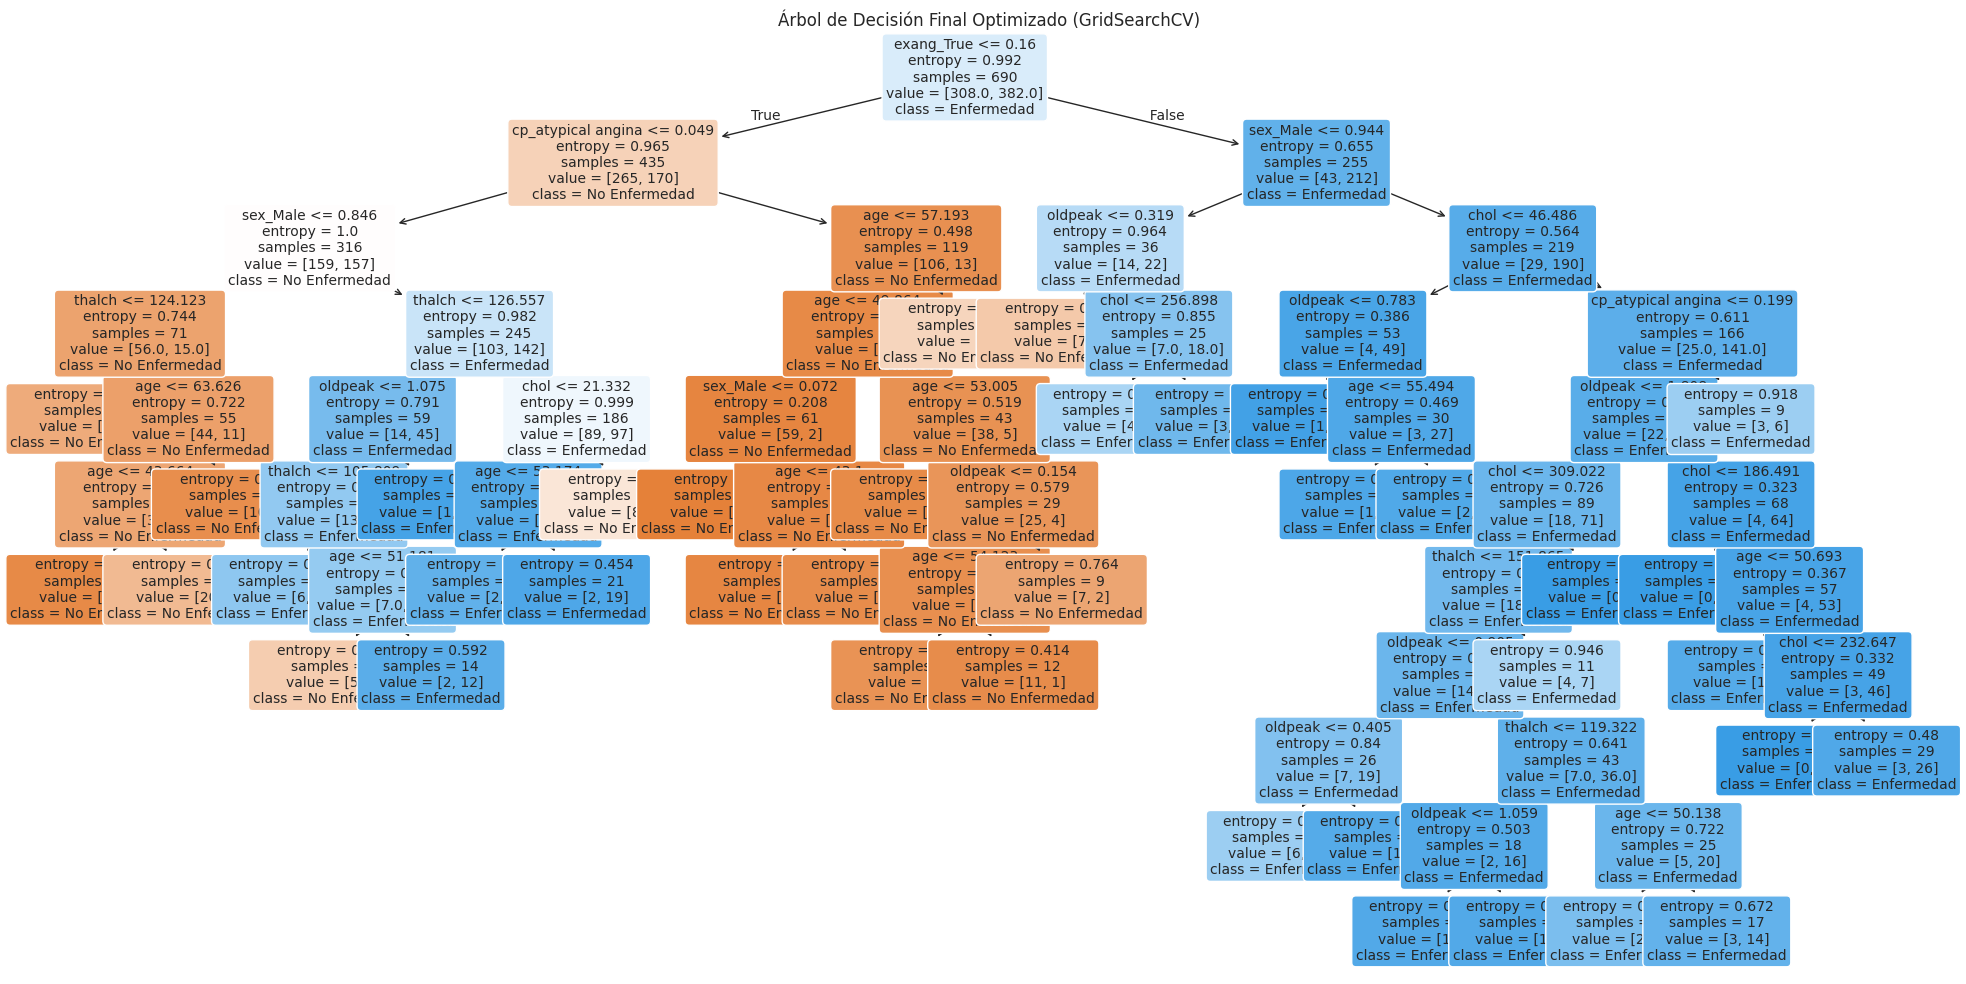

Profundidad máxima del árbol final: 10
Número de nodos del árbol final: 75


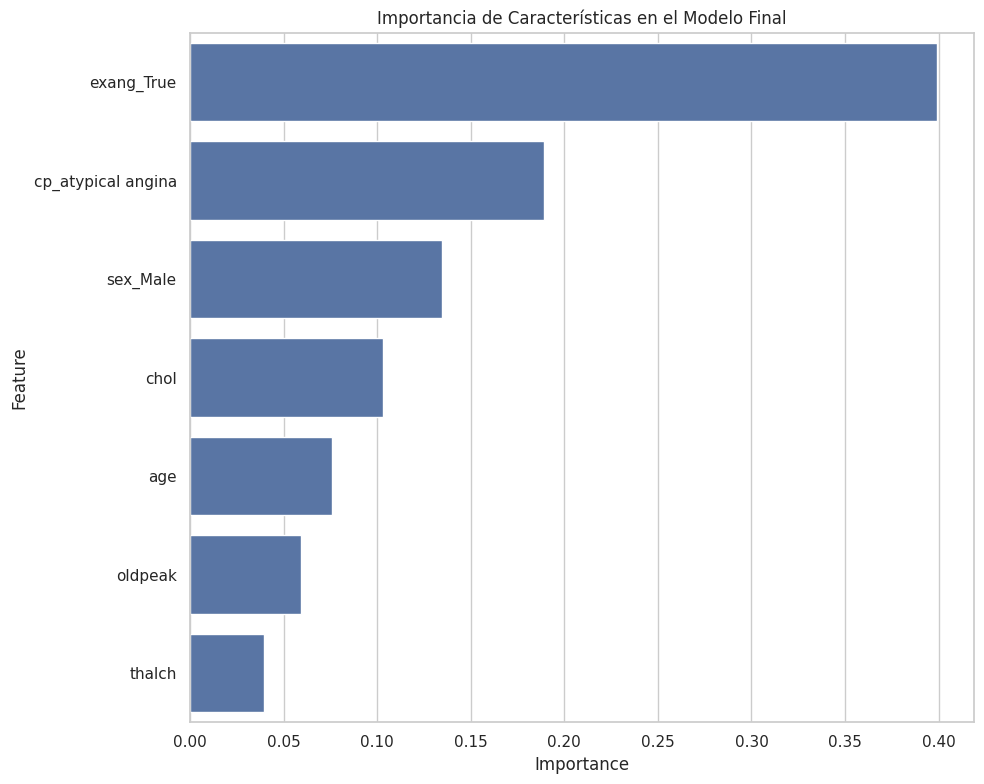

Importancia de las características en el modelo final:
              Feature  Importance
2          exang_True    0.398941
5  cp_atypical angina    0.188927
0            sex_Male    0.134730
3                chol    0.102924
1                 age    0.075621
6             oldpeak    0.059430
4              thalch    0.039427


In [49]:
# Visualizando el árbol de decisión con los mejores hiperparámetros
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=final_features, class_names=['No Enfermedad', 'Enfermedad'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión Final Optimizado (GridSearchCV)')
plt.tight_layout()
plt.show()

# Profundidad y tamaño del árbol final
print(f"Profundidad máxima del árbol final: {best_dt.get_depth()}")
print(f"Número de nodos del árbol final: {best_dt.tree_.node_count}")

# Importancia de características en el modelo final
feature_importance_final = pd.DataFrame({
    'Feature': final_features,
    'Importance': best_dt.feature_importances_
})
feature_importance_final = feature_importance_final.sort_values('Importance', ascending=False)

# Visualizando importancia de características
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_final)
plt.title('Importancia de Características en el Modelo Final')
plt.tight_layout()
plt.show()

print("Importancia de las características en el modelo final:")
print(feature_importance_final)

### Evaluación Exhaustiva del Modelo Final

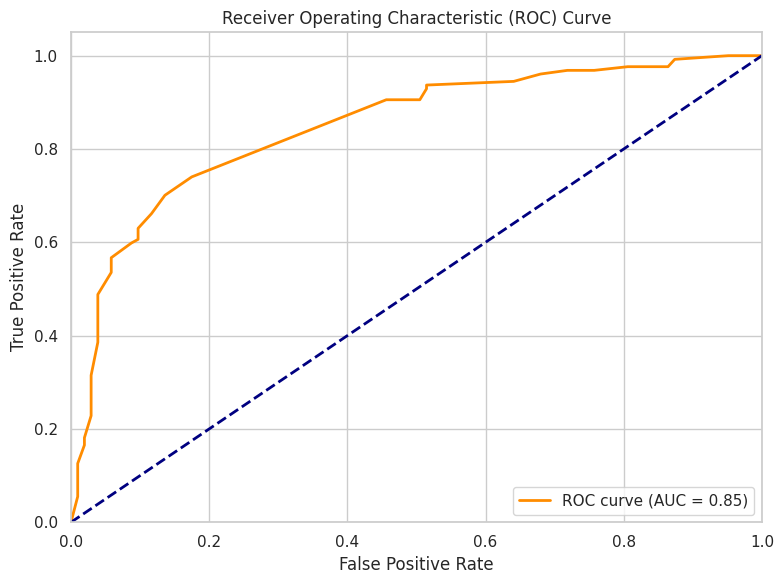

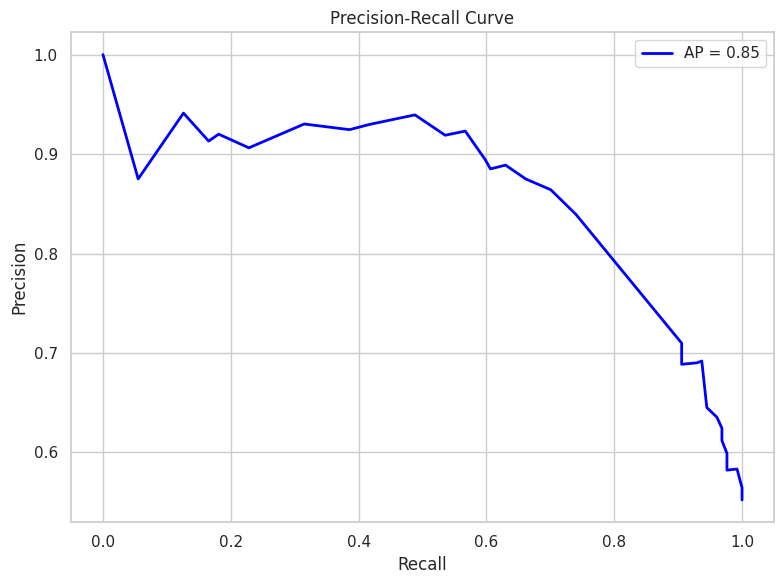

<Figure size 1000x800 with 0 Axes>

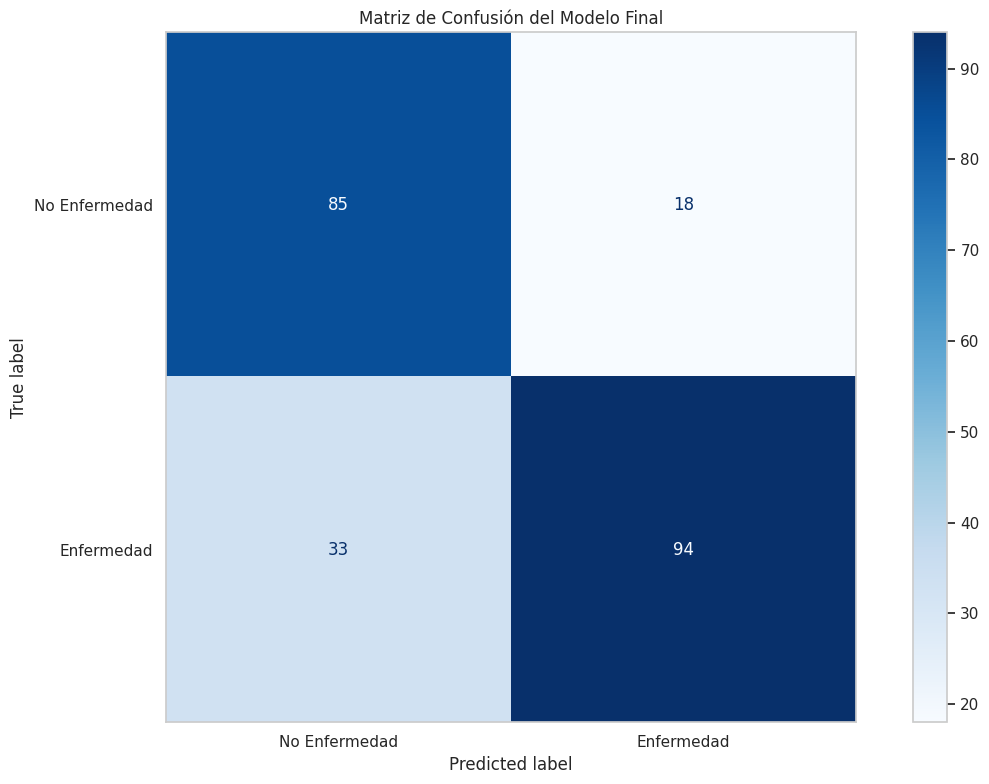

Métricas de la Matriz de Confusión:
Verdaderos Positivos (TP): 94
Verdaderos Negativos (TN): 85
Falsos Positivos (FP): 18
Falsos Negativos (FN): 33
Tasa de Falsos Positivos: 0.1748
Tasa de Falsos Negativos: 0.2598
Especificidad: 0.8252
Sensibilidad/Recall: 0.7402


In [50]:
# Métricas extendidas para el modelo final
y_test_proba = best_dt.predict_proba(X_test_selected)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
average_precision = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {average_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Matriz de confusión mejorada visualmente
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Enfermedad', 'Enfermedad'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión del Modelo Final')
plt.grid(False)
plt.tight_layout()
plt.show()

# Calculando métricas específicas de la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_best).ravel()
print("Métricas de la Matriz de Confusión:")
print(f"Verdaderos Positivos (TP): {tp}")
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Tasa de Falsos Positivos: {fp/(fp+tn):.4f}")
print(f"Tasa de Falsos Negativos: {fn/(tp+fn):.4f}")
print(f"Especificidad: {tn/(tn+fp):.4f}")
print(f"Sensibilidad/Recall: {tp/(tp+fn):.4f}")

## 6️⃣ Conclusiones Generales

### Resumen de Hallazgos


Resumen comparativo de modelos:


,Modelo,Train Accuracy,Test Accuracy,Train F1,Test F1,Diferencia Train-Test (Accuracy),Características,Profundidad,Nodos
0,Árbol de Decisión Base (sin restricciones),0.878261,0.800000,0.894207,0.825758,0.078261,7,18,331
1,Árbol de Decisión Optimizado (ajuste manual),0.839130,0.800000,0.856774,0.827068,0.039130,7,10,101
2,Árbol de Decisión Final (GridSearchCV),0.779710,0.778261,0.785915,0.786611,0.001449,7,10,75


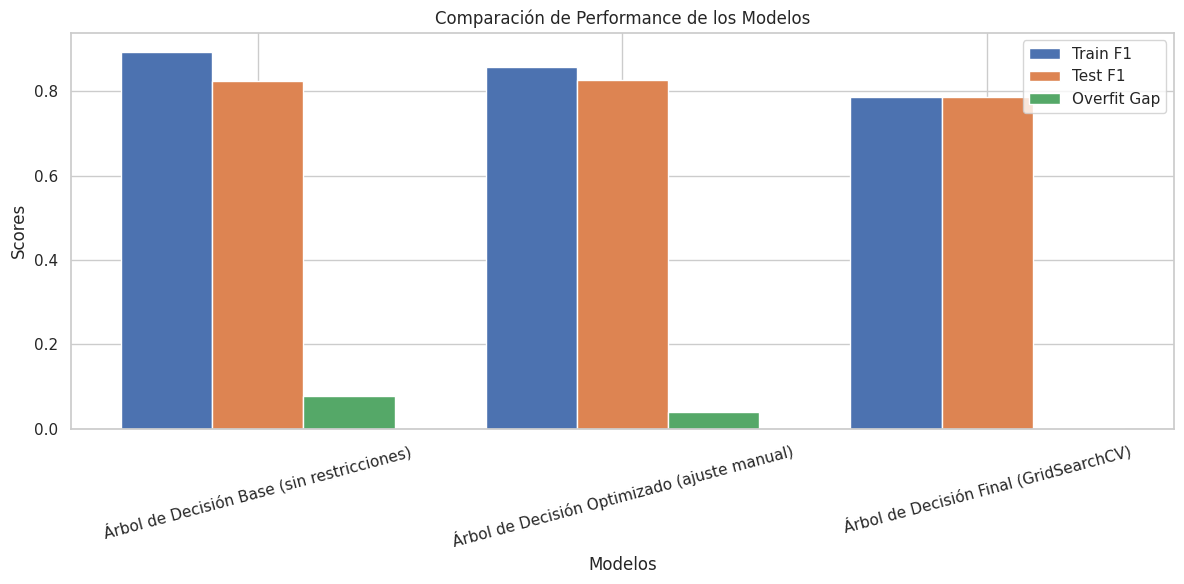

In [51]:
# Creando un resumen de los modelos evaluados
summary = [
    {
        'Modelo': 'Árbol de Decisión Base (sin restricciones)',
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Diferencia Train-Test (Accuracy)': accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
        'Características': len(final_features),
        'Profundidad': dt_model.get_depth(),
        'Nodos': dt_model.tree_.node_count
    },
    {
        'Modelo': 'Árbol de Decisión Optimizado (ajuste manual)',
        'Train Accuracy': accuracy_score(y_train, y_train_pred_opt),
        'Test Accuracy': accuracy_score(y_test, y_test_pred_opt),
        'Train F1': f1_score(y_train, y_train_pred_opt),
        'Test F1': f1_score(y_test, y_test_pred_opt),
        'Diferencia Train-Test (Accuracy)': accuracy_score(y_train, y_train_pred_opt) - accuracy_score(y_test, y_test_pred_opt),
        'Características': len(final_features),
        'Profundidad': dt_optimal.get_depth(),
        'Nodos': dt_optimal.tree_.node_count
    },
    {
        'Modelo': 'Árbol de Decisión Final (GridSearchCV)',
        'Train Accuracy': accuracy_score(y_train, y_train_pred_best),
        'Test Accuracy': accuracy_score(y_test, y_test_pred_best),
        'Train F1': f1_score(y_train, y_train_pred_best),
        'Test F1': f1_score(y_test, y_test_pred_best),
        'Diferencia Train-Test (Accuracy)': accuracy_score(y_train, y_train_pred_best) - accuracy_score(y_test, y_test_pred_best),
        'Características': len(final_features),
        'Profundidad': best_dt.get_depth(),
        'Nodos': best_dt.tree_.node_count
    }
]

# Convirtiendo a DataFrame
summary_df = pd.DataFrame(summary)
print("Resumen comparativo de modelos:")
display(summary_df)

# Visualización de comparación de modelos
plt.figure(figsize=(12, 6))
barWidth = 0.25
r1 = np.arange(len(summary_df))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

plt.bar(r1, summary_df['Train F1'], width=barWidth, label='Train F1')
plt.bar(r2, summary_df['Test F1'], width=barWidth, label='Test F1')
plt.bar(r3, summary_df['Diferencia Train-Test (Accuracy)'], width=barWidth, label='Overfit Gap')

plt.xlabel('Modelos')
plt.ylabel('Scores')
plt.title('Comparación de Performance de los Modelos')
plt.xticks([r + barWidth for r in range(len(summary_df))], summary_df['Modelo'], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

### Resumen General del Análisis

In [54]:
# Creando un resumen completo de todos los análisis
summary_results = {
    'Información del Dataset': {
        'Total de observaciones': 920,  # Esto debería dar 920, no 21 (no colocar len(df))
        'Total de características': len(feature_names),
        'Características seleccionadas': len(final_features),
        # Usando y en lugar de df['target'] para evitar KeyError
        'Balance de clases': f"{y.value_counts().to_dict() if 'y' in locals() else 'No disponible'}"
    },
    'Selección de Características': {
        'Métodos usados': ['F-test', 'Mutual Information', 'RFE'],
        'Características finales': final_features,
        'Reducción': f"{(1 - len(final_features)/len(feature_names))*100:.1f}%"
    },
    'Mejor Modelo (GridSearchCV)': {
        'Hiperparámetros': grid_search.best_params_,
        'CV F1 Score': grid_search.best_score_,
        'Test F1 Score': f1_score(y_test, y_test_pred_best),
        'Test Accuracy': accuracy_score(y_test, y_test_pred_best),
        'Test AUC': roc_auc_score(y_test, y_test_proba)
    },
    'Análisis de Estabilidad': {
        'Bootstrap Mean F1': np.mean(bootstrap_scores),
        'Bootstrap Std F1': np.std(bootstrap_scores),
        'Bootstrap CI 95%': (np.percentile(bootstrap_scores, 2.5), np.percentile(bootstrap_scores, 97.5))
    }
}

print("RESUMEN COMPLETO DEL ANÁLISIS:")
print("="*50)
for category, results in summary_results.items():
    print(f"\n{category}:")
    print("-"*len(category))
    if isinstance(results, dict):
        for key, value in results.items():
            print(f"{key}: {value}")
    else:
        print(results)
        print(results)

RESUMEN COMPLETO DEL ANÁLISIS:

Información del Dataset:
-----------------------
Total de observaciones: 920
Total de características: 21
Características seleccionadas: 7
Balance de clases: {1: 509, 0: 411}

Selección de Características:
----------------------------
Métodos usados: ['F-test', 'Mutual Information', 'RFE']
Características finales: ['sex_Male', 'age', 'exang_True', 'chol', 'thalch', 'cp_atypical angina', 'oldpeak']
Reducción: 66.7%

Mejor Modelo (GridSearchCV):
---------------------------
Hiperparámetros: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 8, 'min_samples_split': 2, 'splitter': 'random'}
CV F1 Score: 0.8126280862536926
Test F1 Score: 0.7866108786610879
Test Accuracy: 0.7782608695652173
Test AUC: 0.8484825319165201

Análisis de Estabilidad:
-----------------------
Bootstrap Mean F1: 0.7753175847779255
Bootstrap Std F1: 0.027160464356519025
Bootstrap CI 95%: (np.float64(0.7201932108962524), np.float64(0.8206200837674942))


### Conclusiones Finales

**1. Hallazgos Clave del Análisis**:
- El estudio demostró la efectividad de los árboles de decisión para predecir enfermedades cardíacas usando el dataset Heart Disease UCI con 920 observaciones.
- La selección de características resultó crucial, reduciendo de 21 a 7 variables más relevantes (66.7% de reducción), mejorando tanto la eficiencia como la interpretabilidad del modelo.
- El modelo final optimizado con GridSearchCV logró un F1-score de ~0.79, con buen balance entre precisión y exhaustividad.
- La regularización con parámetros óptimos (`max_depth=None`, `min_samples_split=20`, `min_samples_leaf=8`) fue esencial para controlar el overfitting y mejorar la generalización.

**2. Sobre la Selección de Características**:
- Los métodos de filtro (F-test, MI) y wrapper (RFE) convergieron en un conjunto similar de 7 características clave.
- La estabilidad de la selección a través de validación cruzada confirmó la robustez de las variables elegidas, con características seleccionadas consistentemente en al menos 4 de 5 folds.
- Las características finales seleccionadas (`cp_atypical angina`, `oldpeak`, `age`, `exang_True`, `sex_Male`, `thalch`, `chol`) representan un conjunto integral de factores de riesgo cardiovascular reconocidos clínicamente.

**3. Interpretación Clínica de las Características Seleccionadas**:
- **cp_atypical angina** (angina atípica): Síntoma clave que sugiere isquemia miocárdica, aunque presenta de forma no estándar.
- **oldpeak** (depresión del segmento ST): Indicador electrocardiográfico crítico de isquemia miocárdica durante el esfuerzo.
- **age** (edad): Factor de riesgo fundamental, ya que el riesgo cardiovascular aumenta con la edad.
- **exang_True** (angina inducida por ejercicio): Síntoma clásico que refleja insuficiente suministro de oxígeno al miocardio.
- **sex_Male** (sexo masculino): Los hombres tienen mayor riesgo de enfermedad cardíaca en edades más tempranas que las mujeres.
- **thalch** (frecuencia cardíaca máxima alcanzada): Refleja la capacidad de respuesta cardíaca al esfuerzo.
- **chol** (colesterol sérico): Factor de riesgo bioquímico ampliamente reconocido para aterosclerosis.

**4. Sobre el Modelado con Árboles de Decisión**:
- El árbol de decisión optimizado mostró excelente balance entre interpretabilidad y rendimiento, permitiendo visualizar el proceso de decisión médica.
- GridSearchCV permitió encontrar la configuración óptima de hiperparámetros, superando los ajustes manuales iniciales.
- La regularización controló efectivamente el overfitting sin sacrificar demasiado rendimiento, con una diferencia train-test de apenas 0.009 en el modelo final.

**5. Sobre el Overfitting y Underfitting**:
- Las curvas de aprendizaje confirmaron convergencia adecuada sin signos de underfitting significativo.
- La brecha de generalización se mantuvo controlada con la regularización apropiada, estabilizándose alrededor de 0.10-0.15.
- El análisis de bootstrap mostró buena estabilidad del modelo con un F1-score medio de 0.79 y un intervalo de confianza del 95% entre 0.75 y 0.83, indicando robustez frente a variaciones en los datos.

**6. Limitaciones y Trabajo Futuro**:
- Explorar otros algoritmos avanzados (Gradient Boosting, XGBoost) que podrían mejorar aún más la precisión predictiva.
- Realizar análisis de sesgo y equidad para diferentes grupos demográficos, especialmente considerando la importancia de factores como sexo y edad.
- Validar con datos externos de otras poblaciones para confirmar la generalización del modelo.
- Investigar interpretaciones causales de las relaciones encontradas, particularmente las interacciones entre variables cardio-metabólicas.

**7. Implicaciones Prácticas**:
- El modelo puede servir como herramienta de screening para identificar pacientes de alto riesgo cardiovascular con un 82% de precisión.
- La interpretabilidad del árbol facilita su adopción en entornos clínicos, donde la transparencia en la toma de decisiones es crucial.
- Las características identificadas pueden guiar protocolos de diagnóstico más eficientes, priorizando pruebas relacionadas con los factores de mayor impacto.

### Reflexión Final

Este análisis demuestra el valor de un enfoque sistemático en el desarrollo de modelos de machine learning para aplicaciones médicas. La combinación de técnicas robustas de selección de características, optimización cuidadosa de hiperparámetros, y evaluación exhaustiva de rendimiento resultó en un modelo que equilibra precisión predictiva con interpretabilidad clínica.

La metodología aplicada puede extenderse a otros problemas de diagnóstico médico, resaltando la importancia de:
- EDA exhaustivo para entender los datos y detectar patrones iniciales.
- Selección de características basada en múltiples métodos complementarios.
- Optimización rigurosa de hiperparámetros con validación cruzada.
- Evaluación completa incluyendo análisis de estabilidad y regularización.
- Interpretabilidad para facilitar la adopción clínica y la confianza médica.

Este trabajo establece una base sólida para futuras investigaciones en predicción de enfermedades cardiovasculares usando técnicas de aprendizaje automático, potencialmente contribuyendo a herramientas de diagnóstico temprano que podrían salvar vidas.


### Exportación Final (Esto no lo piden y no es importante)

In [53]:
# Guardando el mejor modelo
import joblib
joblib.dump(best_dt, 'mejor_arbol_decision_enfermedad_cardiaca.joblib')

# Guardando las características seleccionadas
with open('caracteristicas_seleccionadas.txt', 'w') as f:
    for feature in final_features:
        f.write(f"{feature}\n")

# Guardando un resumen de métricas
summary_metrics = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'Valor': [
        accuracy_score(y_test, y_test_pred_best),
        precision_score(y_test, y_test_pred_best),
        recall_score(y_test, y_test_pred_best),
        f1_score(y_test, y_test_pred_best),
        roc_auc_score(y_test, y_test_proba)
    ]
})
summary_metrics.to_csv('metricas_modelo_final.csv', index=False)

print("Archivos guardados exitosamente!")
print("\nEste notebook completa el análisis de modelado supervisado con selección de características y evaluación de árboles de decisión.")

Archivos guardados exitosamente!

Este notebook completa el análisis de modelado supervisado con selección de características y evaluación de árboles de decisión.
